# 방산 부품 불량 분류 — EDA · 가설검정 · 모델링

전체 데이터 기준(기계 미분리). 진행도 구간 분할 → 피처 → 가설 검정 → 분류 모델.

In [1]:
import pandas as pd, numpy as np, os, glob, datetime, warnings, itertools
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
import seaborn as sns
from scipy.stats import mannwhitneyu, wilcoxon, shapiro
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve)
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
RED = '#FF0000'
GREEN = '#626F47'
BASE="C:/Users/aleet/Desktop/DataAnalysis/내배캠/7_실전프로젝트/data"
OUT=os.path.join(BASE,"산출물")
os.makedirs(OUT,exist_ok=True)
STAMP=datetime.datetime.now().strftime("%Y%m%d_%H%M")

try:
    import xgboost as xgb
    HAS_XGB=True
except Exception:
    HAS_XGB=False

In [2]:
df = pd.read_csv(os.path.join(BASE,"방산.csv"))
s = df["pk_datetime"].astype(str).str.replace("오전","AM").str.replace("오후","PM")
df["pk_datetime"] = pd.to_datetime(s, format="%Y. %m. %d. %p %I:%M:%S", errors="coerce")
df = df.sort_values(["sequence_index","pk_datetime"]).reset_index(drop=True)
df["is_def"] = (df["failure"]==-1).astype(int)
df["power"]  = df["volt"]*df["ampere"]
df.head()

,pk_datetime,rec_num,volt,ampere,temperature,sequence_index,failure,is_def,power
0,2023-11-07 10:14:08,2,0.1,1,16,0,1,0,0.1
1,2023-11-07 10:14:13,2,2.1,166,16,0,1,0,348.6
2,2023-11-07 10:14:18,2,3.8,299,16,0,1,0,1136.2
3,2023-11-07 10:14:23,2,4.0,206,16,0,1,0,824.0
4,2023-11-07 10:14:28,2,4.1,164,16,0,1,0,672.4


## 데이터 구조

In [3]:
fault_no = df[df['is_def']==1]['sequence_index'].unique()
print(f"불량 시퀀스 번호: ", end=' ')
for i in range(len(fault_no)):
    print(f"{fault_no[i]}",end=' ')

불량 시퀀스 번호:  7 8 9 10 34 36 37 38 59 91 98 

In [4]:
print(f"행 {df.shape[0]}  열 {df.shape[1]}  시퀀스 {df.sequence_index.nunique()}  기계 {sorted(df.rec_num.unique())}")
df.info()

part0 = df.groupby("sequence_index").agg(line=("rec_num","first"), label=("failure","first"))
ct = pd.crosstab(part0.line, part0.label, margins=True, margins_name="합계")
ct["불량비율"] = (ct[-1]/ct["합계"]*100).round(2)
display(ct)

행 96901  열 9  시퀀스 100  기계 [np.int64(1), np.int64(2)]
<class 'pandas.DataFrame'>
RangeIndex: 96901 entries, 0 to 96900
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   pk_datetime     96901 non-null  datetime64[us]
 1   rec_num         96901 non-null  int64         
 2   volt            96901 non-null  float64       
 3   ampere          96901 non-null  int64         
 4   temperature     96901 non-null  int64         
 5   sequence_index  96901 non-null  int64         
 6   failure         96901 non-null  int64         
 7   is_def          96901 non-null  int64         
 8   power           96901 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(6)
memory usage: 6.7 MB


label,-1,1,합계,불량비율
line,,,,
1,5,41,46,10.87
2,6,48,54,11.11
합계,11,89,100,11.00


부품 라벨 일관성: 일관적
{'count': 100.0, 'mean': 969.0, 'std': 225.4, 'min': 571.0, '25%': 820.8, '50%': 959.0, '75%': 1050.2, 'max': 1693.0}


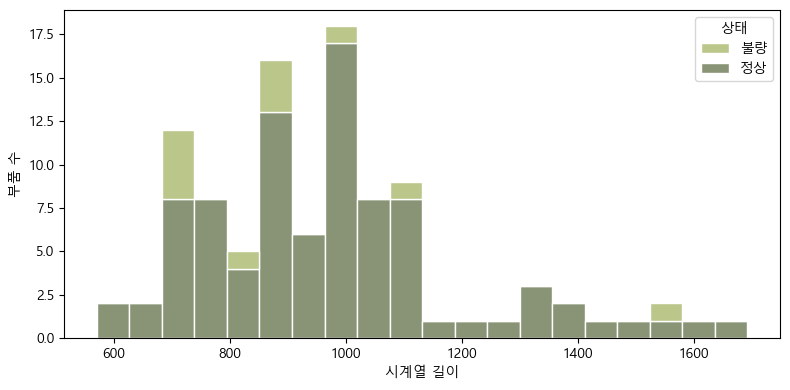

In [5]:
nuniq = df.groupby("sequence_index")["failure"].nunique()
print("부품 라벨 일관성:", "일관적" if (nuniq==1).all() else "불일치 존재")
lengths = df.groupby("sequence_index").size()
print(lengths.describe().round(1).to_dict())

p = df.groupby("sequence_index").agg(length=("failure","size"), label=("failure","first")).reset_index()
p["상태"] = p.label.map({1:"정상",-1:"불량"})
plt.figure(figsize=(8,4))
sns.histplot(data=p, x="length", hue="상태", bins=20, multiple="stack",hue_order=['불량', '정상'], edgecolor='#FFFFFF',
             palette={"정상":"#626F47","불량":'#A4B465'})
plt.xlabel("시계열 길이")
plt.ylabel("부품 수")
plt.tight_layout()
plt.show()

In [6]:
print("결측치\n", df[["ampere","volt","temperature"]].isna().sum().to_dict())
display(df[["ampere","volt","temperature","power"]].describe().round(2))
print("전류 매우 낮은 시점 비율:", round((df.ampere<10).mean(),4))

결측치
 {'ampere': 0, 'volt': 0, 'temperature': 0}


,ampere,volt,temperature,power
count,96901.00,96901.00,96901.00,96901.00
mean,551.45,23.22,12.42,13856.19
std,286.06,6.26,2.17,8060.62
min,0.00,0.00,9.00,0.00
25%,351.00,23.10,11.00,7670.00
50%,545.00,24.70,12.00,14011.20
75%,736.00,27.00,14.00,18816.00
max,1522.00,31.10,18.00,41855.00


전류 매우 낮은 시점 비율: 0.0403


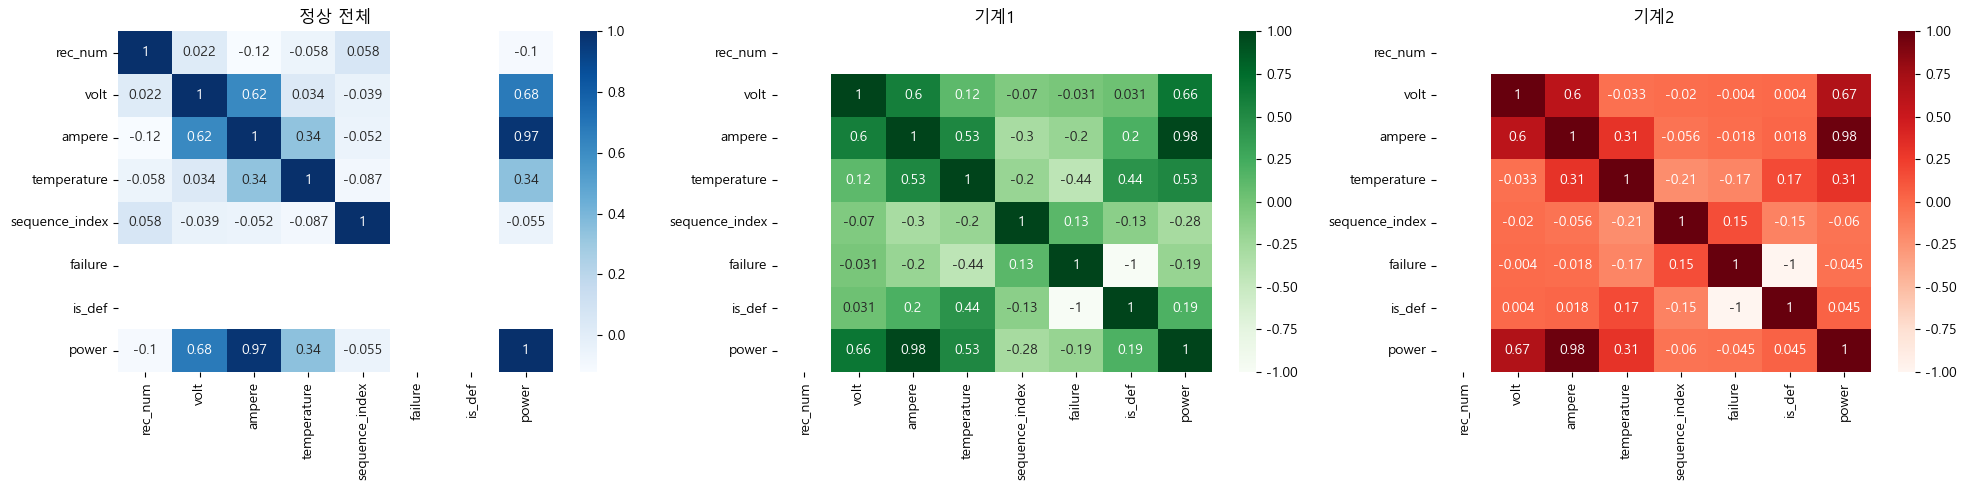

기계1 고상관쌍: [('ampere', 'power', np.float64(0.979)), ('failure', 'is_def', np.float64(-1.0))]
기계2 고상관쌍: [('ampere', 'power', np.float64(0.975)), ('failure', 'is_def', np.float64(-1.0))]


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))
sns.heatmap(df[df.failure==1].corr(numeric_only=True), annot=True, cmap="Blues", ax=ax[0])
ax[0].set_title("정상 전체")
for a, ln, cm in zip(ax[1:], [1,2], ["Greens","Reds"]):
    sns.heatmap(df[df.rec_num==ln].corr(numeric_only=True), annot=True, cmap=cm, ax=a)
    a.set_title(f"기계{ln}")
plt.tight_layout()
plt.show()

for ln in [1,2]:
    cm = df[df.rec_num==ln].corr(numeric_only=True)
    hi = [(a,b,round(cm.loc[a,b],3)) for a,b in itertools.combinations(cm.columns,2) if abs(cm.loc[a,b])>0.9]
    print(f"기계{ln} 고상관쌍:", hi if hi else "없음")

<Axes: >

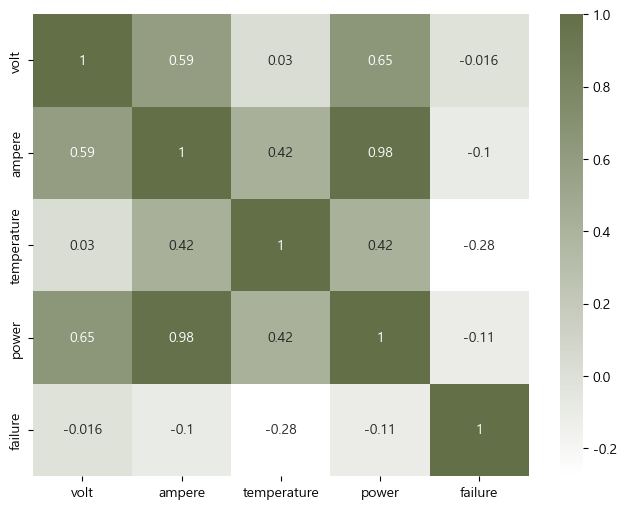

In [8]:
from matplotlib.colors import LinearSegmentedColormap

my_colors = ['#FFFFFF','#626F47']
my_cmap = LinearSegmentedColormap.from_list("custom_cmap", my_colors)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[['volt','ampere','temperature','power','failure']].corr(numeric_only=True), annot=True, cmap=my_cmap)

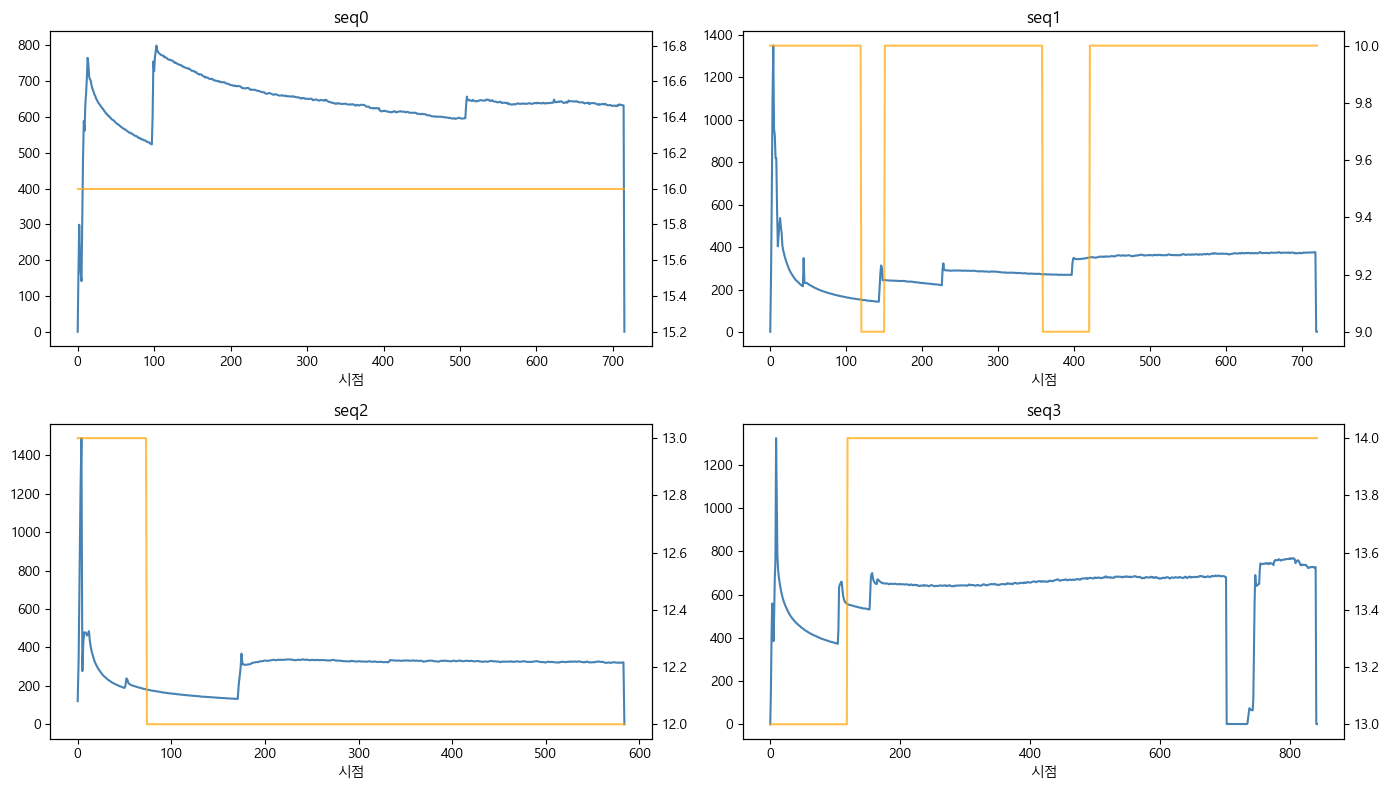

In [9]:
ids = df[df.failure==1].sequence_index.unique()[:4]
fig, axes = plt.subplots(2, 2, figsize=(14,8))
for ax, sid in zip(axes.flat, ids):
    g = df[df.sequence_index==sid].reset_index(drop=True)
    ax.plot(range(len(g)), g.ampere, color="steelblue", label="전류")
    ax2 = ax.twinx()
    ax2.plot(range(len(g)), g.temperature, color="orange", alpha=.7, label="온도")
    ax.set_title(f"seq{sid}")
    ax.set_xlabel("시점")
plt.tight_layout()
plt.show()

([<matplotlib.patches.Wedge at 0x217a8f993d0>,
 [Text(0.3469960843655509, -1.0438360586964677, ''),
  Text(-0.34699611754545556, 1.043836047666673, '')])

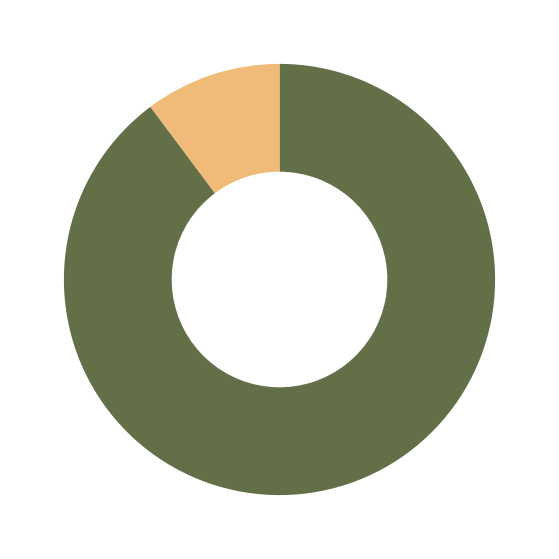

In [10]:
fig,ax = plt.subplots(figsize=(9,7))
plt.pie(data=df,x=df['failure'].value_counts(),radius=1,colors=['#626F47','#F0BB78'],startangle=90,counterclock=False, wedgeprops={'width': 0.5})

## 전처리 · 구간 분할

진행도 0–100%를 초기 / 전환점 / 본공정 / 종료 네 구간으로 나눈다.

In [11]:
g = df.groupby("sequence_index")
df["pos"]   = g.cumcount()
df["n_seq"] = g["rec_num"].transform("size")
df["prog"]  = df["pos"]/(df["n_seq"]-1)*100
df["seg"]   = np.select([df.prog<20, df.prog<40, df.prog<80], [1,2,3], default=4)
SEG_NAME = {1:"초기",2:"전환점",3:"본공정",4:"종료"}
print("구간별 행수:", df.seg.value_counts().sort_index().to_dict())

구간별 행수: {1: 19396, 2: 19363, 3: 38720, 4: 19422}


In [12]:
off_all = np.zeros(len(df), bool)
ev_all = np.zeros(len(df), bool)
for sid, idx in df.groupby("sequence_index").groups.items():
    idx = np.array(idx)
    sub = df.loc[idx]
    active = ((sub.ampere>100)&(sub.volt>5)).values
    off = np.zeros(len(sub), bool)
    if active.any():
        i0,i1 = np.where(active)[0][[0,-1]]
        win = np.zeros(len(sub), bool)
        win[i0:i1+1] = True
        off = (sub.volt.values<5) & win
    off_all[idx] = off
    ev_all[idx]  = off & (~np.concatenate([[False], off[:-1]]))
df["off_mid"] = off_all
df["event_start"] = ev_all

ev = df.groupby("sequence_index").agg(is_def=("is_def","first"), 중단횟수=("event_start","sum"))
print("정상·불량 평균 중단횟수")
print(ev.groupby("is_def")["중단횟수"].mean().round(2).rename({0:"정상",1:"불량"}))

정상·불량 평균 중단횟수
is_def
정상    1.35
불량    0.82
Name: 중단횟수, dtype: float64


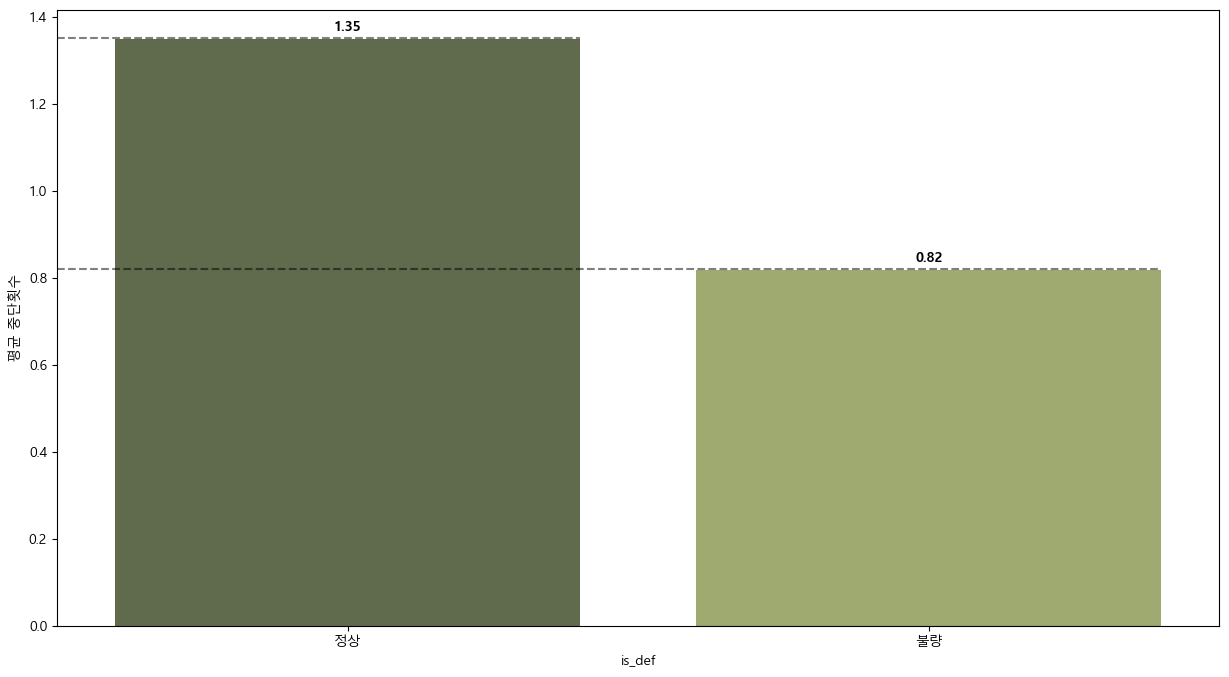

In [13]:
plt.figure(figsize=(15,8))
means = ev.groupby("is_def")["중단횟수"].mean().round(2)
ax = sns.barplot(data=ev, x="is_def", y="중단횟수", estimator=np.mean, ci=None,
            palette=["#626F47","#A4B465"])
for i, (idx, val) in enumerate(means.items()):
    ax.text(i, val + 0.01, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
plt.axhline(1.35,0,0.45,color='black',linestyle='--',alpha=0.5)
plt.axhline(0.82,0,0.95,color='black',linestyle='--',alpha=0.5)
plt.xlabel("is_def")
plt.ylabel("평균 중단횟수")
plt.xticks(means.index, ["정상", "불량"])
plt.show()

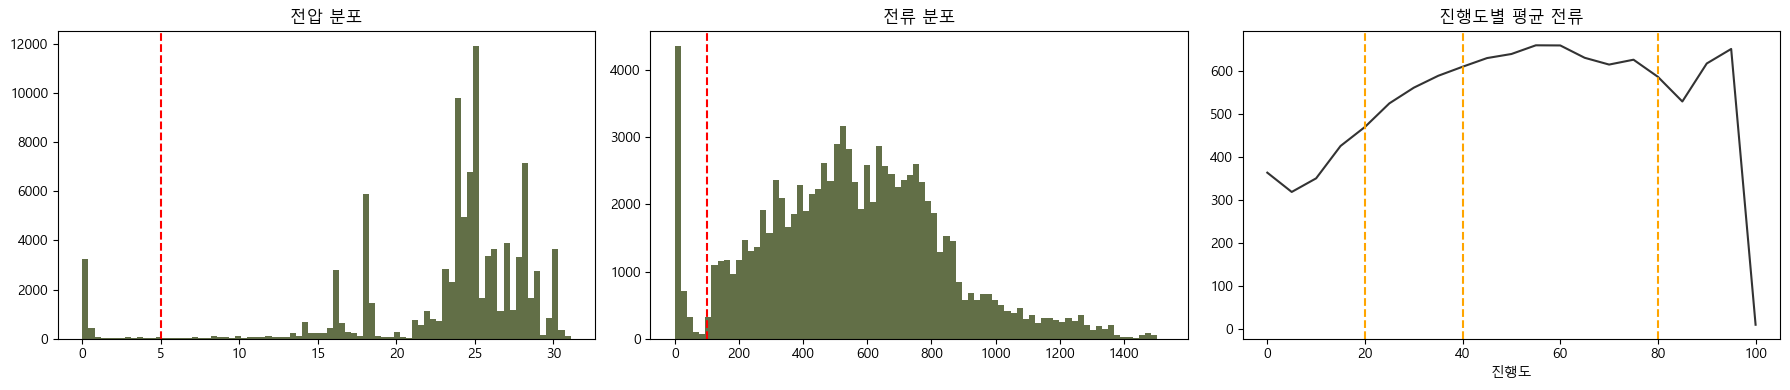

네 구간 미만 시퀀스: 0
구간 내 라벨 불일치: 0


In [14]:
fig, ax = plt.subplots(1, 3, figsize=(18,4))
ax[0].hist(df.volt, bins=80, color="#626F47")
ax[0].axvline(5, color=RED, ls="--")
ax[0].set_title("전압 분포")
ax[1].hist(df.ampere, bins=80, color="#626F47")
ax[1].axvline(100, color=RED, ls="--")
ax[1].set_title("전류 분포")
binmean = df.assign(pb=df.prog//5*5).groupby("pb")[["volt","ampere","temperature"]].mean()
ax[2].plot(binmean.index, binmean.ampere, color="#333")
for b in [20,40,80]: ax[2].axvline(b, color="orange", ls="--")
ax[2].set_title("진행도별 평균 전류")
ax[2].set_xlabel("진행도")
plt.tight_layout()
plt.show()

nseg = df.groupby("sequence_index").seg.nunique()
print("네 구간 미만 시퀀스:", int((nseg<4).sum()))
print("구간 내 라벨 불일치:", int((df.groupby(['sequence_index','seg']).is_def.nunique()>1).sum()))

## 피처

구간별 통계·추세·상호작용·도메인 + 부품 단위 + 정상기준 절대이탈 |z|.

In [15]:
VAL = ["volt","ampere","temperature","power"]
def seg_features(sub):
    sub = sub.sort_values("prog")
    o = {}
    for c in VAL:
        v = sub[c].values
        x = sub.prog.values
        o[f"{c}_mean"]=v.mean()
        o[f"{c}_std"]=v.std(ddof=0)
        o[f"{c}_min"]=v.min()
        o[f"{c}_max"]=v.max()
        o[f"{c}_slope"]=np.polyfit(x,v,1)[0] if (len(v)>=2 and np.ptp(x)>0) else 0.0
    o["amp_temp_corr"] = (np.corrcoef(sub.ampere,sub.temperature)[0,1]
                          if len(sub)>2 and sub.ampere.std()>0 and sub.temperature.std()>0 else 0.0)
    r = (sub.volt/sub.ampere.replace(0,np.nan)).replace([np.inf,-np.inf],np.nan)
    o["resistance_mean"]=r.mean()
    o["n_off"]=int(sub.off_mid.sum())
    o["n_int"]=int(sub.event_start.sum())
    return pd.Series(o)

seg_tbl = df.groupby(["sequence_index","seg"]).apply(seg_features, include_groups=False).reset_index()
lab = df.groupby("sequence_index").agg(is_def=("is_def","first"), rec=("rec_num","first")).reset_index()
seg_tbl = seg_tbl.merge(lab, on="sequence_index")
seg_tbl["resistance_mean"] = seg_tbl["resistance_mean"].fillna(seg_tbl["resistance_mean"].median())

fcols = [c for c in seg_tbl.columns if c not in ["sequence_index","seg","is_def","rec","n_off"]]
wide = seg_tbl.pivot(index="sequence_index", columns="seg", values=fcols)
wide.columns = [f"{a}_s{b}" for a,b in wide.columns]
wide = wide.reset_index().merge(lab, on="sequence_index").fillna(0)
print("seg_tbl", seg_tbl.shape, "| wide", wide.shape)

seg_tbl (400, 28) | wide (100, 95)


In [16]:
ZONES = [(0,.2),(.2,.4),(.4,.8),(.8,1.0)]
def part_features(g):
    g = g.reset_index(drop=True)
    n = len(g)
    o = {}
    for c in VAL:
        o[f"{c}_mean"]=g[c].mean()
        o[f"{c}_std"]=g[c].std()
        o[f"{c}_max"]=g[c].max()
        o[f"{c}_range"]=g[c].max()-g[c].min()
    hot = g[g.temperature>=g.temperature.median()]
    o["hot_amp"]=hot.ampere.mean()
    o["hot_volt"]=hot.volt.mean()
    d = np.diff(g.ampere.values)
    run=mx=0
    for v in d:
        run = run+1 if v<0 else 0
        mx=max(mx,run)
    o["drop_run"]=mx
    mu,sd = g.ampere.mean(), g.ampere.std()+1e-9
    zs = [abs((g.iloc[int(n*lo):int(n*hi)].ampere.mean()-mu)/sd) for lo,hi in ZONES]
    o["within_max_dev"]=max(zs)
    o["within_n_dev"]=sum(v>1 for v in zs)
    ex = np.where(((g.ampere-mu)/sd).abs().values>2)[0]
    o["first_exit_pos"] = ex[0]/n if len(ex) else 1.0
    return pd.Series(o)

part = df.groupby("sequence_index").apply(part_features, include_groups=False).reset_index()
part = part.merge(df.groupby("sequence_index").agg(label=("failure","first"),
                  rec=("rec_num","first")).reset_index(), on="sequence_index")
part["상태"] = part.label.map({1:"정상",-1:"불량"})

for c in ["ampere_mean","volt_mean","power_mean","temperature_mean",
          "ampere_max","ampere_range","hot_amp","hot_volt","first_exit_pos","ampere_std","drop_run"]:
    nm = part.loc[part.label==1, c]
    part[f"{c}_absz"] = ((part[c]-nm.mean())/nm.std()).abs()
y = (part.label==-1).astype(int).values
part.head()

,sequence_index,volt_mean,volt_std,volt_max,volt_range,ampere_mean,ampere_std,ampere_max,ampere_range,temperature_mean,...,volt_mean_absz,power_mean_absz,temperature_mean_absz,ampere_max_absz,ampere_range_absz,hot_amp_absz,hot_volt_absz,first_exit_pos_absz,ampere_std_absz,drop_run_absz
0,0,20.407961,2.756948,21.9,21.8,638.653631,70.807432,798.0,797.0,16.000000,...,1.700609,0.102700,2.186390,0.343189,0.341465,0.303552,1.426473,0.314034,1.612389,0.306391
1,1,24.562413,4.559573,27.6,27.5,306.148405,100.029906,1349.0,1347.0,9.871012,...,0.813322,1.431221,1.349136,1.881190,1.879466,1.369251,0.443647,0.314034,1.233814,0.497603
2,2,23.283590,4.486769,26.1,25.7,293.401709,99.202027,1488.0,1487.0,12.126496,...,0.039484,1.584112,0.048053,2.442330,2.444794,1.472337,0.152331,0.299863,1.244540,0.430603
3,3,25.168090,6.690665,29.0,29.0,607.442467,167.530973,1325.0,1325.0,13.858837,...,1.179828,0.650027,0.951254,1.784302,1.790628,0.247686,1.222377,0.314034,0.359343,3.579579
4,4,24.727055,7.226522,28.4,28.4,592.589041,178.840360,762.0,761.0,14.944064,...,0.912950,0.542979,1.577270,0.488521,0.486835,0.247216,1.182345,0.314034,0.212831,3.311581


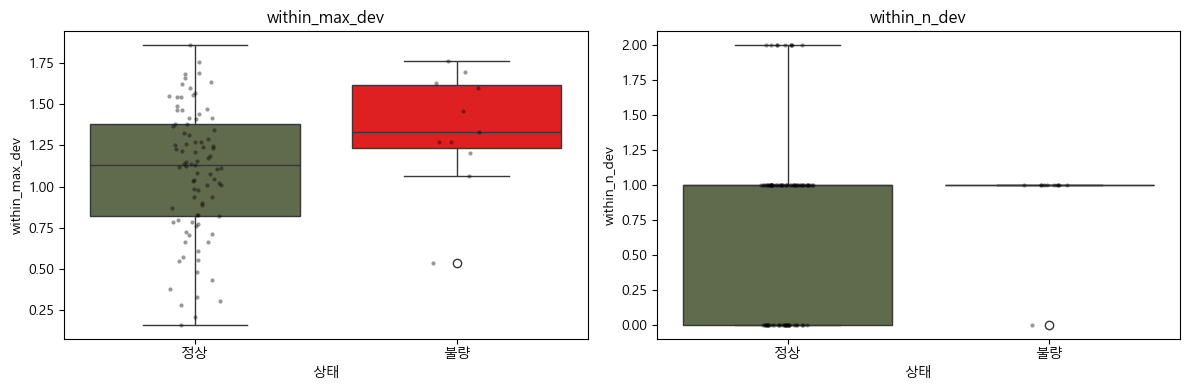

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, col in zip(axes, ["within_max_dev","within_n_dev"]):
    sns.boxplot(data=part, x="상태", y=col, palette={"정상":GREEN,"불량":RED}, ax=ax)
    sns.stripplot(data=part, x="상태", y=col, color="black", alpha=.4, size=3, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 모수 검정 vs 비모수 검정
#### 정규성 검정을 통한 검정 방법 선택

  기계           변수        W          p      정규성
------------------------------------------------------------
volt_mean                W=0.974 p=0.0742        정규
volt_std                 W=0.964 p=0.0149       비정규
ampere_mean              W=0.986 p=0.4748        정규
ampere_std               W=0.960 p=0.0075       비정규
temperature_mean         W=0.943 p=0.0007       비정규
temperature_std          W=0.938 p=0.0003       비정규
power_mean               W=0.979 p=0.1474        정규
power_std                W=0.957 p=0.0049       비정규
hot_amp                  W=0.982 p=0.2477        정규
hot_volt                 W=0.972 p=0.0520        정규
ampere_mean_absz         W=0.903 p=0.0000       비정규
volt_mean_absz           W=0.945 p=0.0009       비정규
power_mean_absz          W=0.907 p=0.0000       비정규
temperature_mean_absz    W=0.945 p=0.0009       비정규
hot_amp_absz             W=0.919 p=0.0000       비정규
ampere_max_absz          W=0.922 p=0.0000       비정규
ampere_range_absz        W=0.922 p=0.0000       비정규
hot_amp_

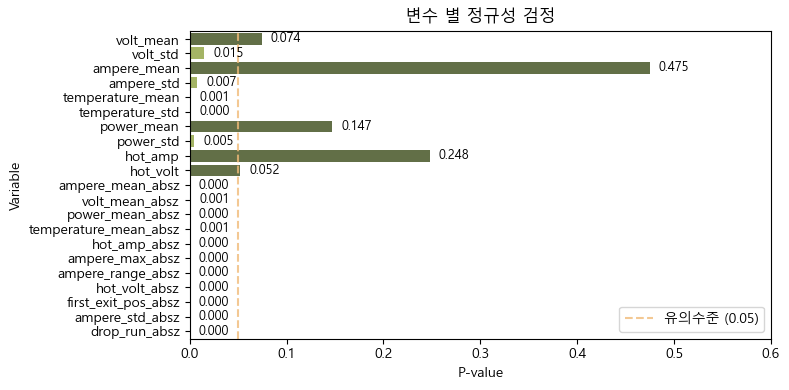


해석: p<0.05 → 정규성 기각(비정규) → 비모수 검정(MWU 등) 사용이 타당


In [18]:
from matplotlib.patches import Patch

print(f"{'기계':>4} {'변수':>12} {'W':>8} {'p':>10} {'정규성':>8}")
print("-"*60)
feat_list = ['volt_mean', 'volt_std', 'ampere_mean', 'ampere_std',
          'temperature_mean', 'temperature_std', 'power_mean', 'power_std', 'hot_amp', 'hot_volt',
          'ampere_mean_absz', 'volt_mean_absz', 'power_mean_absz', 'temperature_mean_absz',
           'hot_amp_absz', 'ampere_max_absz', 'ampere_range_absz','hot_amp_absz', 'hot_volt_absz', 'first_exit_pos_absz','ampere_std_absz', 'drop_run_absz']
for c in feat_list:
    W,p = shapiro(part.loc[part.label==1,c].dropna())
    verdict='정규' if p>=0.05 else '비정규'
    print(f"{c:24s} W={W:.3f} p={p:.4f}  {verdict:>8}")

    norm_results = []
    for c in feat_list:
        W, p = shapiro(part.loc[part.label==1, c].dropna())
        norm_results.append({"Variable": c, "Statistic": round(W, 3), "P-value": round(p, 4)})

    norm_df = pd.DataFrame(norm_results)

plt.figure(figsize=(8, 4))
sns.barplot(x='P-value', y='Variable', data=norm_df, palette='Greens')
plt.axvline(x=0.05, color='#F0BB78', linestyle='--', label='유의수준 (0.05)',alpha=0.8)
plt.title('변수 별 정규성 검정')
alpha = 0.05
ax = plt.gca()
colors = ['#626F47' if v >= alpha else '#A4B465' for v in norm_df['P-value']]
for patch, c in zip(ax.patches, colors):
    patch.set_facecolor(c)

offset = norm_df['P-value'].max() * 0.02
xmax = max(norm_df['P-value'].max() * 1.12, 0.6)
ax.set_xlim(0, xmax)
for patch, pval in zip(ax.patches, norm_df['P-value']):
    x = patch.get_width()
    y = patch.get_y() + patch.get_height() / 2
    ax.text(x + offset, y, f"{pval:.3f}", va='center', fontsize=9)

ax.set_xlabel('P-value')

ax.legend([Patch(facecolor='#626F47'), Patch(facecolor='#A4B465')], ['p >= 0.05', 'p < 0.05'])
plt.legend()
plt.tight_layout()
plt.show()

print("\n해석: p<0.05 → 정규성 기각(비정규) → 비모수 검정(MWU 등) 사용이 타당")

## 가설 검정

- 가설1 기계1·2 정상 가동수준 차이
- 가설3 부품 자기기준 구간 이탈
- 가설4 평균 전류·전력 이탈
- 가설5 고온구간 전류·전압
- 가설6 전류 변동성·하락구간
- 가설7 평균 전압 이탈
- 가설8 초기 이상신호

#### **가설 1 : 가동수준**
- $H_0$ : rec_num1과 rec_num2의 정상 가동 수준이 같다.
- $H_1$ : rec_num1과 rec_num2의 정상 가동 수준이 다르다.

|    **검정방법**    |  **비교단위**   | **파생변수** |
|:--------------:|:-----------:|:--------:|
| Mann-Whitney U | 기계1,2의 정상부품 | 피쳐 별 평균  |


#### **가설 2 : 불량 유형 별 시그니처** — ⚠️ 미검정 (데이터 한계로 제외)
- $H_0$ : 불량 유형 별로 시그니처가 같다. 
- $H_1$ : 불량 유형 별로 시그니처가 다르다.

| **검정방법** | **비교단위** | **파생변수** |
|:--------:|:--------:|:--------:|
|Kruskal-Wallis|불량 유형|불량 유형 라벨

> `failure`는 정상/불량 이진 라벨뿐이라 불량 *유형*을 구분할 수 없음 → 다집단(Kruskal-Wallis) 비교 불가, 본 분석에서 제외.


##### **가설 3: 윈도우 값**
- $H_0$ : 불량의 윈도우 값이 같은 부품의 기준 분포 내에 존재한다.
- $H_1$ : 불량의 윈도우 값이 같은 부품의 기준 분포 밖에 존재한다.

| **검정방법** | **비교단위** | **파생변수** |
|:--------:|:--------:|:--------:|
|Mann-Whitney U|부품 단위|이탈 윈도우 수


#### **가설 4: 평균 전류·전력 기준 미달** 
- $H_0$ : 평균 전류·전력이 정상 기준보다 낮아도 산화피막 목표 미달 불량이 아니다. 
- $H_1$ : 평균 전류·전력이 정상 기준보다 낮으면 산화피막 목표 미달 불량이다.

|    **검정방법**    | **비교단위** |   **파생변수**    |
|:--------------:|:--------:|:-------------:|
| Mann-Whitney U |  정상과 불량  | 기계 별 평균 전류·전력 |


#### **가설 5: 온도와 전류·전압**
- $H_0$ : 온도가 임계값 이상인 구간에서 전류·전압이 높게 유지되거나 전체 평균 전류·전압이 높아도 버닝 불량이 아니다.
- $H_1$ : 온도가 임계값 이상인 구간에서 전류·전압이 높게 유지되거나 전체 평균 전류·전압이 높으면 버닝 불량이다.

|    **검정방법**    | **비교단위** |    **파생변수**    |
|:--------------:|:--------:|:--------------:|
| Mann-Whitney U |  정상과 불량  | 고온 구간 평균 전류·전압 |


#### **가설 6: 전류 표준편차와 하락 불안정 구간**
- $H_0$ : 전류 표준편차가 크고 전류 하락 불안정 구간이 길어도 피막 두께 불균일 불량이 아니다.
- $H_1$ : 전류 표준편차가 크고 전류 하락 불안정 구간이 길면 피막 두께 불균일 불량이다.

|    **검정방법**    | **비교단위** |      **파생변수**      |
|:--------------:|:--------:|:------------------:|
| Mann-Whitney U |  정상과 불량  | 전류 표준편차, 불안정 구간 길이 |


#### **가설 7: 평균 전압**
- $H_0$ : 평균 전압이 정상 범위를 초과해도 변색 불량이 아니다.
- $H_1$ : 평균 전압이 정상 범위를 초과하면 변색 불량이다.

|    **검정방법**    | **비교단위** |  **파생변수**  |
|:--------------:|:--------:|:----------:|
| Mann-Whitney U |  정상과 불량  | 기계 별 평균 전압 |


#### **가설 8: 초기 이상신호**
- $H_0$ : 불량은 초반 일정 시간 안에 이상 신호가 나타나지 않는다.
- $H_1$ : 불량은 초반 일정 시간 안에 이상 신호가 나타난다.

|    **검정방법**    | **비교단위** |  **파생변수**   |
|:--------------:|:--------:|:-----------:|
| Mann-Whitney U |  정상과 불량  | 첫 이상 윈도우 위치 |


불량은 양방향으로 흩어져 단방향 평균은 상쇄된다. 정상기준 절대이탈 |z| 로 방향 무관 검정한다.

In [19]:
def mwu(d, col, alt, g="label", pos=-1, neg=1):
    a=d[d[g]==pos][col].dropna()
    b=d[d[g]==neg][col].dropna()
    U,p = mannwhitneyu(a,b,alternative=alt)
    return p, 1-2*U/(len(a)*len(b)), a.median(), b.median()

#### **가설 1 : 가동수준**
- $H_0$ : rec_num1과 rec_num2의 정상 가동 수준이 같다.
- $H_1$ : rec_num1과 rec_num2의 정상 가동 수준이 다르다.

|    **검정방법**    |  **비교단위**   | **파생변수** |
|:--------------:|:-----------:|:--------:|
| Mann-Whitney U | 기계1,2의 정상부품 | 피쳐 별 평균  |

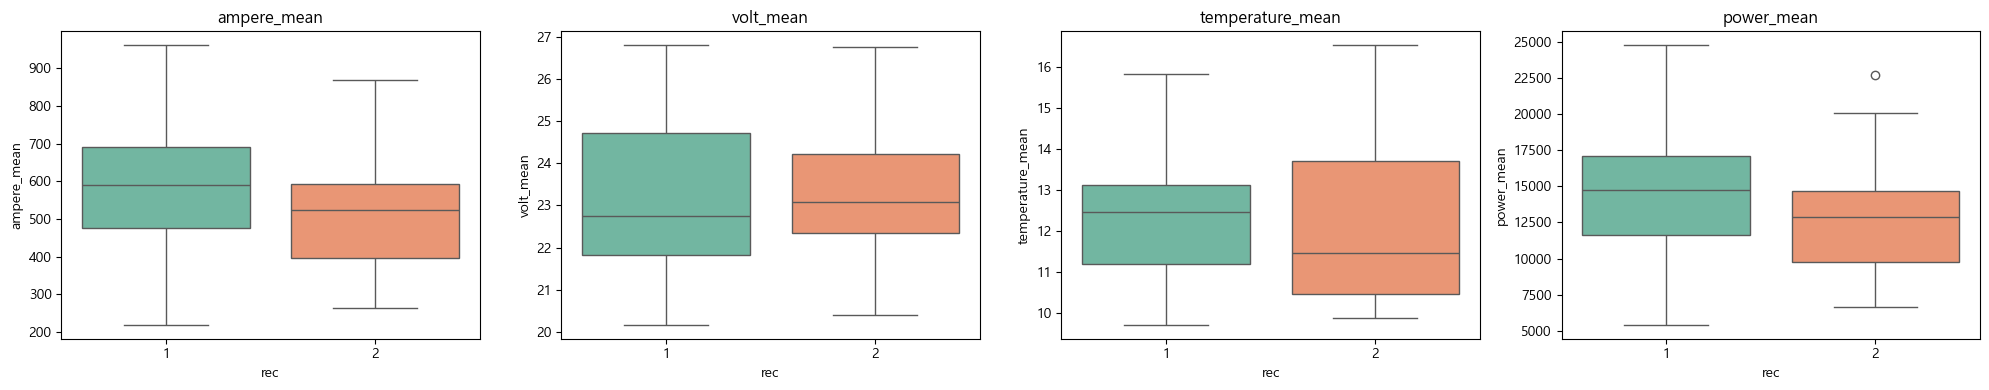

ampere_mean  기계1 589.2 vs 기계2 523.0  p=0.0224  차이
volt_mean    기계1 22.7 vs 기계2 23.1  p=0.4663  동일
temperature_mean 기계1 12.5 vs 기계2 11.5  p=0.1948  동일
power_mean   기계1 14707.3 vs 기계2 12857.7  p=0.0496  차이


In [20]:
nrm = part[part.label==1]
fig, axes = plt.subplots(1, 4, figsize=(20,4))
for ax, col in zip(axes, ["ampere_mean","volt_mean",'temperature_mean',"power_mean"]):
    sns.boxplot(data=nrm, x="rec", y=col, hue="rec", legend=False, palette="Set2", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
for col in ["ampere_mean","volt_mean","temperature_mean","power_mean"]:
    p,e,m1,m2 = mwu(nrm, col, "two-sided", g="rec", pos=1, neg=2)
    print(f"{col:12s} 기계1 {m1:.1f} vs 기계2 {m2:.1f}  p={p:.4f}  {'차이' if p<0.05 else '동일'}")

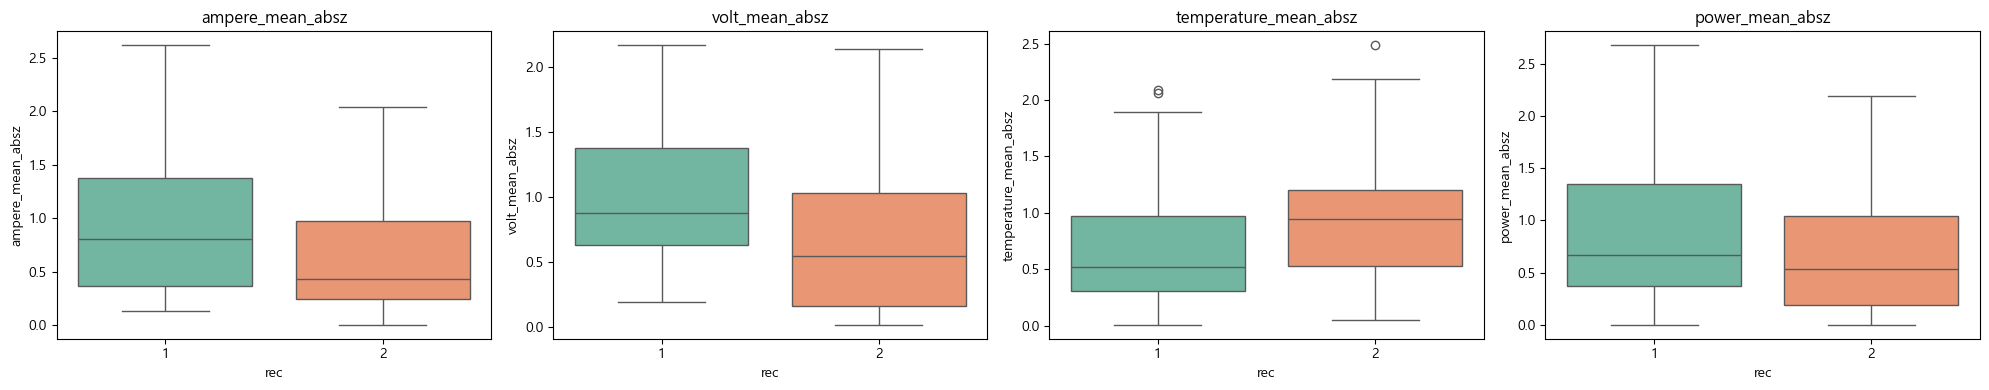

ampere_mean_absz 기계1 0.8 vs 기계2 0.4  p=0.0154  차이
volt_mean_absz 기계1 0.9 vs 기계2 0.5  p=0.0025  차이
temperature_mean_absz 기계1 0.5 vs 기계2 0.9  p=0.9902  동일
power_mean_absz 기계1 0.7 vs 기계2 0.5  p=0.0294  차이


In [21]:
nrm = part[part.label==1]
fig, axes = plt.subplots(1, 4, figsize=(20,4))
for ax, col in zip(axes, ["ampere_mean_absz","volt_mean_absz",'temperature_mean_absz',"power_mean_absz"]):
    sns.boxplot(data=nrm, x="rec", y=col, hue="rec", legend=False, palette="Set2", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
for col in ["ampere_mean_absz","volt_mean_absz","temperature_mean_absz","power_mean_absz"]:
    p,e,m1,m2 = mwu(nrm, col, "greater", g="rec", pos=1, neg=2)
    print(f"{col:12s} 기계1 {m1:.1f} vs 기계2 {m2:.1f}  p={p:.4f}  {'차이' if p<0.05 else '동일'}")

##### **가설 3: 윈도우 값**
- $H_0$ : 불량의 윈도우 값이 같은 부품의 기준 분포 내에 존재한다.
- $H_1$ : 불량의 윈도우 값이 같은 부품의 기준 분포 밖에 존재한다.

| **검정방법** | **비교단위** | **파생변수** |
|:--------:|:--------:|:--------:|
|Mann-Whitney U|부품 단위|이탈 윈도우 수

전류           단방향=0.1607 양측검정=0.0000 ★유의
전압           단방향=0.1402 양측검정=0.0010 ★유의
온도           단방향=0.0363 양측검정=0.0003 ★유의


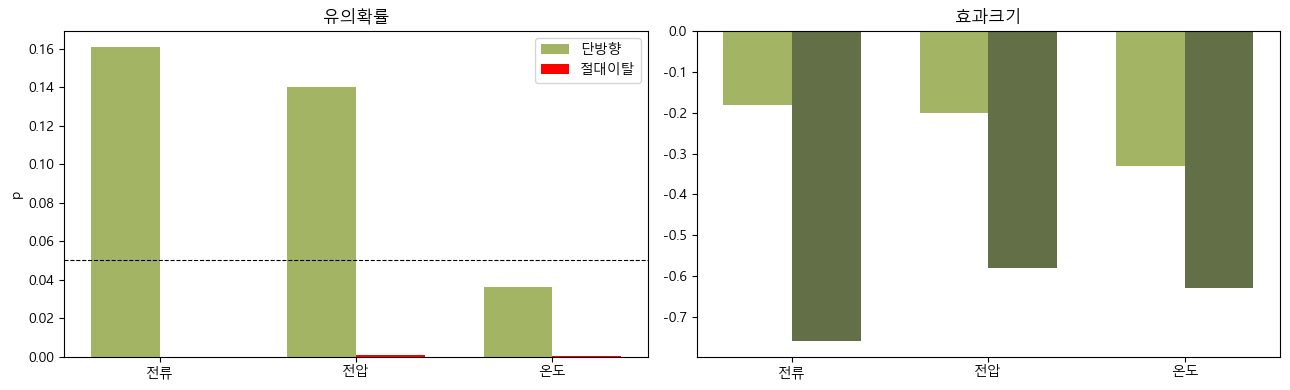

In [22]:
az = "ampere_mean_absz"
pairs = [("전류","ampere_mean","greater","ampere_mean_absz"),
         ("전압","volt_mean","greater","volt_mean_absz"),
         ("온도","temperature_mean","greater","temperature_mean_absz")]
rows=[]
for nm,raw,alt,az in pairs:
    p1,e1,_,_ = mwu(part, raw, alt, g='label', pos=-1, neg=1)
    p2,e2,_,_ = mwu(part, az, "greater", g='label',pos=-1, neg=1)
    rows.append({"피처":nm,"단방향 p":round(p1,3),"단방향 효과":round(e1,2),"|z| p":round(p2,4),"|z| 효과":round(e2,2)})
    flag = '★유의' if (p2 is not None and p2<0.05) else ''
    print(f"{nm:12s} 단방향={p1:.4f} 양측검정={p2:.4f} {'★유의' if p2<0.05 else ''}")
cmp = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(13,4))
x=np.arange(len(cmp))
w=.35
ax[0].bar(x-w/2, cmp["단방향 p"], w, color="#A4B465", label="단방향")
ax[0].bar(x+w/2, cmp["|z| p"], w, color=RED, label="절대이탈")
ax[0].axhline(0.05, color="black", ls="--", lw=.8)
ax[0].set_xticks(x)
ax[0].set_xticklabels(cmp.피처)
ax[0].set_ylabel("p")
ax[0].set_title("유의확률")
ax[0].legend()

ax[1].bar(x-w/2, cmp["단방향 효과"], w, color="#A4B465")
ax[1].bar(x+w/2, cmp["|z| 효과"], w, color="#626F47")
ax[1].set_xticks(x)
ax[1].set_xticklabels(cmp.피처)
ax[1].set_title("효과크기")
plt.tight_layout()
plt.show()

#### **가설 4: 평균 전류·전력 기준 미달**
- $H_0$ : 평균 전류·전력이 정상 기준보다 낮아도 산화피막 목표 미달 불량이 아니다.
- $H_1$ : 평균 전류·전력이 정상 기준보다 낮으면 산화피막 목표 미달 불량이다.

|         **검정방법**          | **비교단위** |   **파생변수**    |
|:------------------------:|:--------:|:-------------:|
| Mann-Whitney U (단방향 less) |  정상과 불량  | 기계 별 평균 전류·전력 |

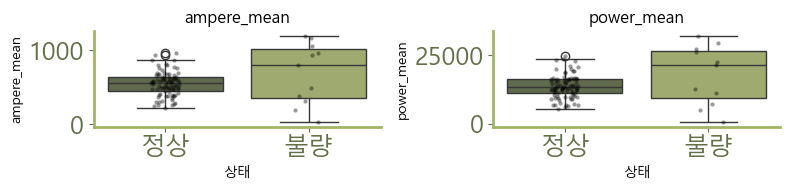

ampere_mean: p=0.1607 효과=-0.18 (불량 804.4 / 정상 555.8) 
power_mean: p=0.1283 효과=-0.21 (불량 21403.9 / 정상 13254.5) 
주: 불량은 양방향으로 흩어져 단순 '미달'로는 잡히지 않음 → 절대이탈 |z|(가설3)이 타당함을 재확인


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(8,2))
for ax, col in zip(axes, ["ampere_mean","power_mean"]):
    sns.boxplot(data=part, x="상태", y=col, palette={"정상":"#626F47","불량":"#A4B465"}, ax=ax)
    sns.stripplot(data=part, x="상태", y=col, color="black", alpha=.4, size=3, ax=ax)
    ax.set_title(col)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color("#A4B465")
    ax.spines['bottom'].set_color("#A4B465")
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params(axis='x',direction='out', colors="#626F47", labelsize=18)
    ax.tick_params(axis='y',direction='out', colors="#626F47", labelsize=18)
plt.tight_layout()
plt.show()
for col in ["ampere_mean","power_mean"]:
    p,e,md_,mn_ = mwu(part, col, "greater")
    flag='★유의' if p<0.05 else ''
    print(f"{col}: p={p:.4f} 효과={e:.2f} (불량 {md_:.1f} / 정상 {mn_:.1f}) {flag}")
print("주: 불량은 양방향으로 흩어져 단순 '미달'로는 잡히지 않음 → 절대이탈 |z|(가설3)이 타당함을 재확인")

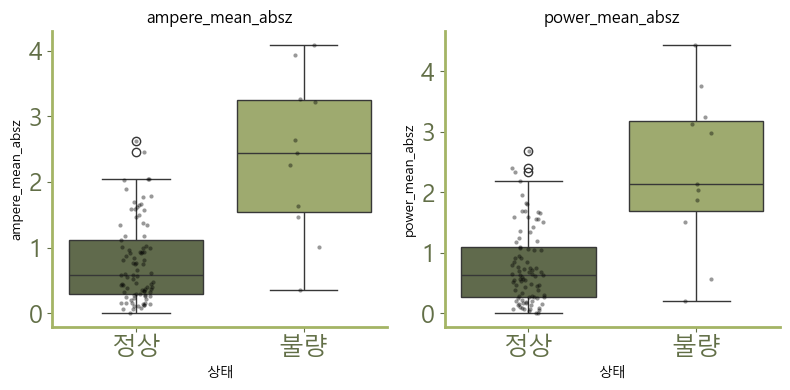

ampere_mean_absz: p=0.000021842 효과=-0.76 (불량 2.4 / 정상 0.6) ★유의
power_mean_absz: p=0.000082413 효과=-0.70 (불량 2.1 / 정상 0.6) ★유의
절대이탈 |z|(가설3)이 타당함


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(8,4))
for ax, col in zip(axes, ["ampere_mean_absz","power_mean_absz"]):
    sns.boxplot(data=part, x="상태", y=col, palette={"정상":"#626F47","불량":"#A4B465"}, ax=ax)
    sns.stripplot(data=part, x="상태", y=col, color="black", alpha=.4, size=3, ax=ax)
    ax.set_title(col)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color("#A4B465")
    ax.spines['bottom'].set_color("#A4B465")
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params(axis='x',direction='out', colors="#626F47", labelsize=18)
    ax.tick_params(axis='y',direction='out', colors="#626F47", labelsize=18)
plt.tight_layout()
plt.show()
for col in ["ampere_mean_absz","power_mean_absz"]:
    p,e,md_,mn_ = mwu(part, col, "greater")
    flag='★유의' if p<0.05 else ''
    print(f"{col}: p={p:.9f} 효과={e:.2f} (불량 {md_:.1f} / 정상 {mn_:.1f}) {flag}")
print("절대이탈 |z|(가설3)이 타당함")

#### **가설 5: 온도와 전류·전압**
- $H_0$ : 온도가 임계값 이상인 구간에서 전류·전압이 높게 유지되거나 전체 평균 전류·전압이 높아도 버닝 불량이 아니다.
- $H_1$ : 온도가 임계값 이상인 구간에서 전류·전압이 높게 유지되거나 전체 평균 전류·전압이 높으면 버닝 불량이다.

|    **검정방법**    | **비교단위** |    **파생변수**    |
|:--------------:|:--------:|:--------------:|
| Mann-Whitney U |  정상과 불량  | 고온 구간 평균 전류·전압 |

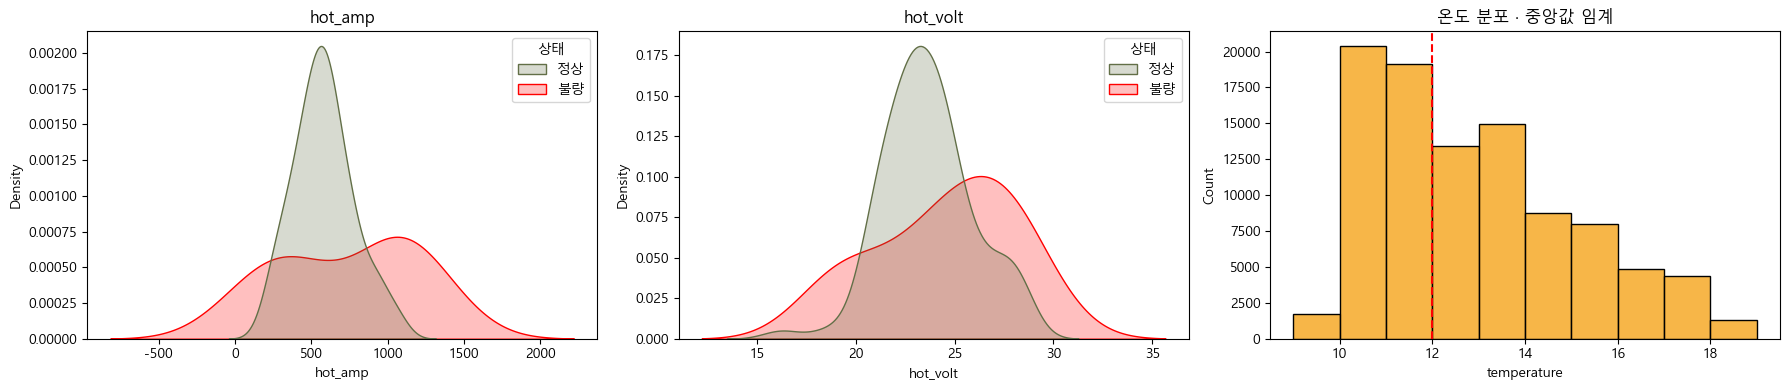

hot_amp: p=0.1502 효과=-0.19 (불량 900.2 / 정상 571.4) 
hot_volt: p=0.1192 효과=-0.22 (불량 24.6 / 정상 23.3) 


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
for ax, col in zip(axes[:2], ["hot_amp","hot_volt"]):
    sns.kdeplot(data=part, x=col, hue="상태", fill=True, common_norm=False,
                palette={"정상":GREEN,"불량":RED}, ax=ax); ax.set_title(col)
sns.histplot(df.temperature, bins=range(int(df.temperature.min()),int(df.temperature.max())+2),
             color="#f59e0b", ax=axes[2]); axes[2].axvline(df.temperature.median(), color=RED, ls="--")
axes[2].set_title("온도 분포 · 중앙값 임계")
plt.tight_layout()
plt.show()
for col in ["hot_amp","hot_volt"]:
    p,e,md_,mn_ = mwu(part, col, "greater")
    flag='★유의' if (p is not None and p<0.05) else ''
    print(f"{col}: p={p:.4f} 효과={e:.2f} (불량 {md_:.1f} / 정상 {mn_:.1f}) {flag}")

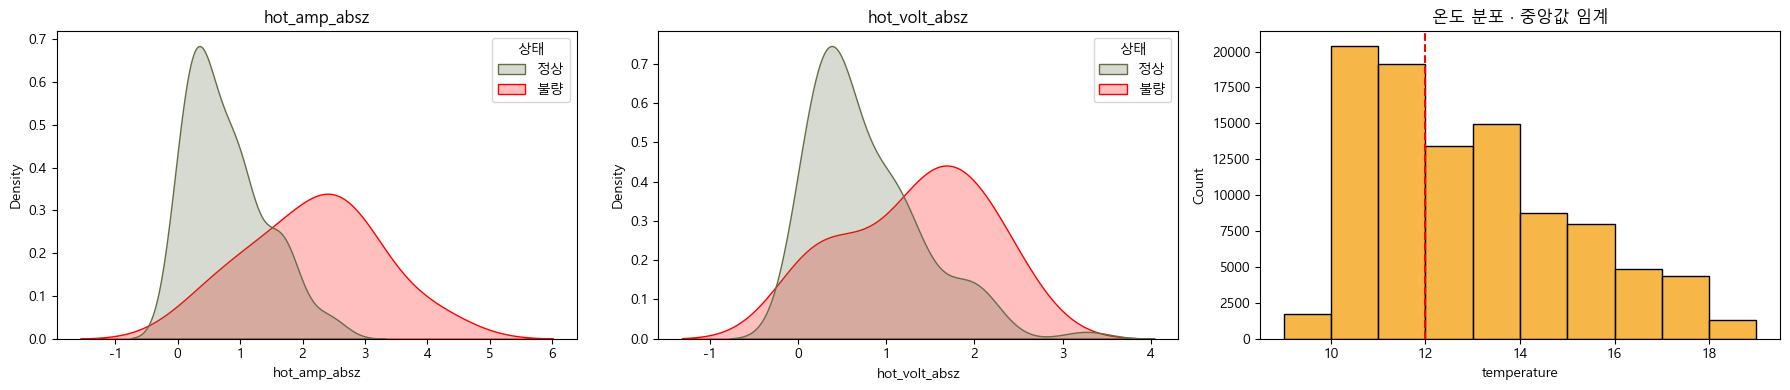

hot_amp_absz: p=0.000034908 효과=-0.74 (불량 2.4 / 정상 0.6) ★유의
hot_volt_absz: p=0.014180441 효과=-0.41 (불량 1.5 / 정상 0.6) ★유의


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
for ax, col in zip(axes[:2], ["hot_amp_absz","hot_volt_absz"]):
    sns.kdeplot(data=part, x=col, hue="상태", fill=True, common_norm=False,
                palette={"정상":GREEN,"불량":RED}, ax=ax); ax.set_title(col)
sns.histplot(df.temperature, bins=range(int(df.temperature.min()),int(df.temperature.max())+2),
             color="#f59e0b", ax=axes[2]); axes[2].axvline(df.temperature.median(), color=RED, ls="--")
axes[2].set_title("온도 분포 · 중앙값 임계")
plt.tight_layout()
plt.show()
for col in ["hot_amp_absz","hot_volt_absz"]:
    p,e,md_,mn_ = mwu(part, col, "greater")
    flag='★유의' if (p is not None and p<0.05) else ''
    print(f"{col}: p={p:.9f} 효과={e:.2f} (불량 {md_:.1f} / 정상 {mn_:.1f}) {flag}")

In [27]:
for col in ["hot_amp", "hot_volt"]:
    nm = part.loc[part.label==1, col]
    part[f"{col}_absz"] = ((part[col] - nm.mean()) / nm.std()).abs()

print("── 가설5 기계별 검정 (통합 상쇄 확인용) ──")
for col in ["hot_amp", "hot_volt"]:
    for rec in [1, 2]:
        sub = part[part.rec == rec]
        p, e, md_, mn_ = mwu(sub, col, "greater")
        flag = "★유의" if p < 0.05 else ""
        print(f"  기계{rec} {col}: p={p:.4f} 효과={e:.2f} "
              f"(불량{md_:.1f}/정상{mn_:.1f}) {flag}")
print("  → 기계1은 고온전류 유의, 기계2는 방향 반대 → 통합 시 상쇄\n")

── 가설5 기계별 검정 (통합 상쇄 확인용) ──
  기계1 hot_amp: p=0.0274 효과=-0.53 (불량1045.5/정상612.6) ★유의
  기계2 hot_amp: p=0.6212 효과=0.08 (불량455.5/정상541.9) 
  기계1 hot_volt: p=0.2459 효과=-0.20 (불량24.1/정상23.3) 
  기계2 hot_volt: p=0.1977 효과=-0.22 (불량25.7/정상23.4) 
  → 기계1은 고온전류 유의, 기계2는 방향 반대 → 통합 시 상쇄



In [28]:
print("\n가설5 기계별")
for col in ["hot_amp_absz", "hot_volt_absz"]:
    print(f"  {col}:")
    for rec in [1, 2]:
        sub = part[part.rec == rec]
        p, e, md_, mn_ = mwu(sub, col, "greater")
        flag = "★유의" if p < 0.05 else ""
        print(f"    기계{rec}: p={p:.4f} 효과={e:.2f} (불량 {md_:.1f} / 정상 {mn_:.1f}) {flag}")
    p_all, e_all, _, _ = mwu(part, col, "greater")
    print(f"    통합 : p={p_all:.4f} 효과={e_all:.2f}")
print("  → hot_amp는 기계1에서만 유의(p=0.03). 기계2는 방향 반대라 통합 시 상쇄됨.")
print("    버닝(고온 고전류)이 기계1 특유 불량 패턴임을 시사.")


가설5 기계별
  hot_amp_absz:
    기계1: p=0.0001 효과=-0.91 (불량 2.8 / 정상 0.8) ★유의
    기계2: p=0.0060 효과=-0.62 (불량 1.7 / 정상 0.5) ★유의
    통합 : p=0.0000 효과=-0.74
  hot_volt_absz:
    기계1: p=0.5813 효과=0.05 (불량 1.0 / 정상 0.7) 
    기계2: p=0.0014 효과=-0.72 (불량 1.9 / 정상 0.5) ★유의
    통합 : p=0.0142 효과=-0.41
  → hot_amp는 기계1에서만 유의(p=0.03). 기계2는 방향 반대라 통합 시 상쇄됨.
    버닝(고온 고전류)이 기계1 특유 불량 패턴임을 시사.


#### **가설 6: 전류 표준편차와 하락 불안정 구간**
- $H_0$ : 전류 표준편차가 크고 전류 하락 불안정 구간이 길어도 피막 두께 불균일 불량이 아니다.
- $H_1$ : 전류 표준편차가 크고 전류 하락 불안정 구간이 길면 피막 두께 불균일 불량이다.

|    **검정방법**    | **비교단위** |      **파생변수**      |
|:--------------:|:--------:|:------------------:|
| Mann-Whitney U |  정상과 불량  | 전류 표준편차, 불안정 구간 길이 |

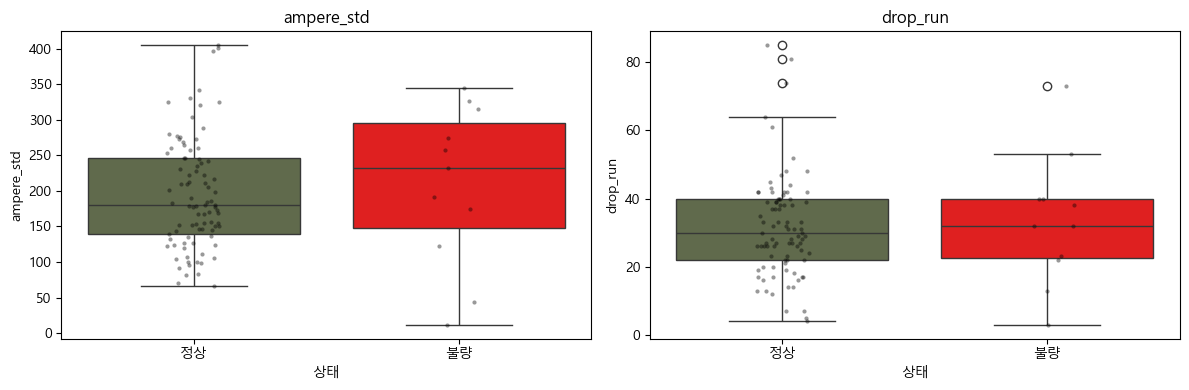

ampere_std: p=0.2106 효과=-0.15 
drop_run: p=0.3704 효과=-0.06 


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, col in zip(axes, ["ampere_std","drop_run"]):
    sns.boxplot(data=part, x="상태", y=col, palette={"정상":GREEN,"불량":RED}, ax=ax)
    sns.stripplot(data=part, x="상태", y=col, color="black", alpha=.4, size=3, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
for col in ["ampere_std","drop_run"]:
    p,e,md_,mn_ = mwu(part, col, "greater")
    flag='★유의' if (p is not None and p<0.05) else ''
    print(f"{col}: p={p:.4f} 효과={e:.2f} {flag}")

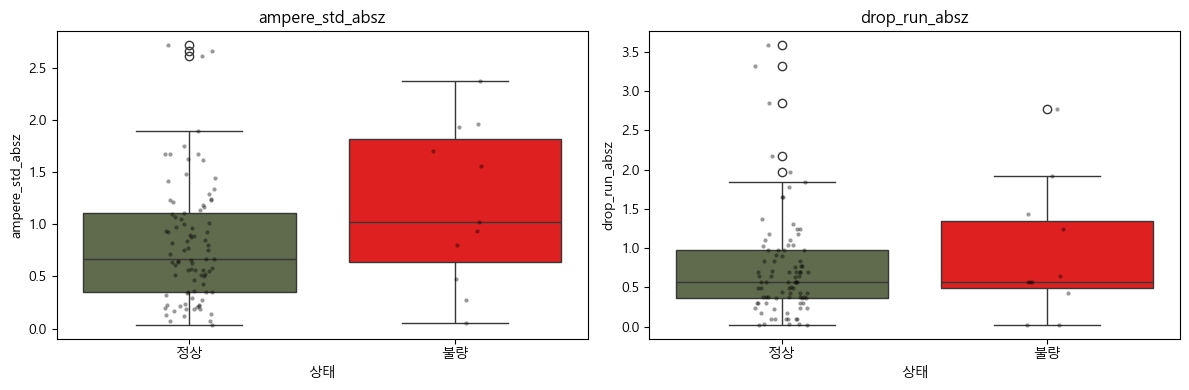

ampere_std_absz: p=0.0527 효과=-0.30 
drop_run_absz: p=0.2945 효과=-0.10 


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, col in zip(axes, ["ampere_std_absz","drop_run_absz"]):
    sns.boxplot(data=part, x="상태", y=col, palette={"정상":GREEN,"불량":RED}, ax=ax)
    sns.stripplot(data=part, x="상태", y=col, color="black", alpha=.4, size=3, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
for col in ["ampere_std_absz","drop_run_absz"]:
    p,e,md_,mn_ = mwu(part, col, "greater")
    flag='★유의' if (p is not None and p<0.05) else ''
    print(f"{col}: p={p:.4f} 효과={e:.2f} {flag}")

#### **가설 7: 평균 전압**
- $H_0$ : 평균 전압이 정상 범위를 초과해도 변색 불량이 아니다.
- $H_1$ : 평균 전압이 정상 범위를 초과하면 변색 불량이다.

|    **검정방법**    | **비교단위** |  **파생변수**  |
|:--------------:|:--------:|:----------:|
| Mann-Whitney U |  정상과 불량  | 기계 별 평균 전압 |

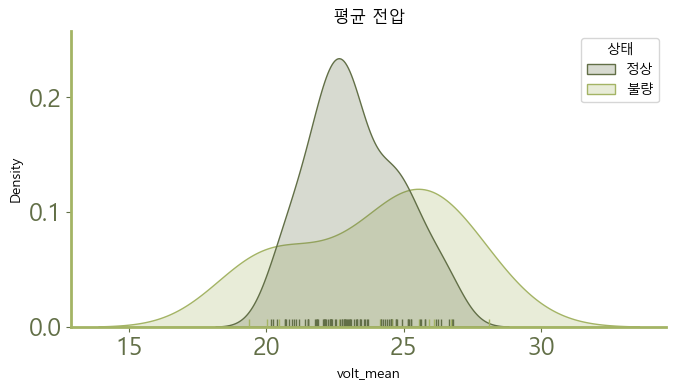

volt_mean: p=0.1402 효과=-0.20 


In [31]:
fig, ax = plt.subplots(figsize=(7,4))
sns.kdeplot(data=part, x="volt_mean", hue="상태", fill=True, common_norm=False, palette={"정상":"#626F47","불량":"#A4B465"}, ax=ax)
sns.rugplot(data=part, x="volt_mean", hue="상태", palette={"정상":"#626F47","불량":"#A4B465"}, legend=False, ax=ax)
ax.set_title("평균 전압")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color("#A4B465")
ax.spines['bottom'].set_color("#A4B465")
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='x',direction='out', colors="#626F47", labelsize=18)
ax.tick_params(axis='y',direction='out', colors="#626F47", labelsize=18)
plt.tight_layout()
plt.show()

for col in ["volt_mean"]:
    p,e,md_,mn_ = mwu(part, col, "greater", g='label', pos=-1, neg=1)
    flag='★유의' if (p is not None and p<0.05) else ''
    print(f"{col}: p={p:.4f} 효과={e:.2f} {flag}")

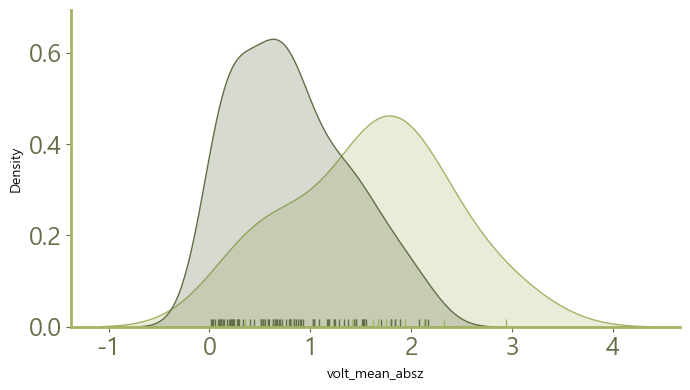

volt_mean_absz: p=0.0010 효과=-0.58 ★유의


In [32]:
fig, ax = plt.subplots(figsize=(7,4))
sns.kdeplot(data=part, x="volt_mean_absz", hue="상태", fill=True, common_norm=False, palette={"정상":"#626F47","불량":"#A4B465"},legend=False, ax=ax)
sns.rugplot(data=part, x="volt_mean_absz", hue="상태", palette={"정상":"#626F47","불량":"#A4B465"}, legend=False, ax=ax)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color("#A4B465")
ax.spines['bottom'].set_color("#A4B465")
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='x',direction='out', colors="#626F47", labelsize=18)
ax.tick_params(axis='y',direction='out', colors="#626F47", labelsize=18)
plt.tight_layout()
plt.show()

for col in ["volt_mean_absz"]:
    p,e,md_,mn_ = mwu(part, col, "greater", g='label', pos=-1, neg=1)
    flag='★유의' if (p is not None and p<0.05) else ''
    print(f"{col}: p={p:.4f} 효과={e:.2f} {flag}")

#### **가설 8: 초기 이상신호**
- $H_0$ : 불량은 초반 일정 시간 안에 이상 신호가 나타나지 않는다.
- $H_1$ : 불량은 초반 일정 시간 안에 이상 신호가 나타난다.

|    **검정방법**    | **비교단위** |  **파생변수**   |
|:--------------:|:--------:|:-----------:|
| Mann-Whitney U |  정상과 불량  | 첫 이상 윈도우 위치 |


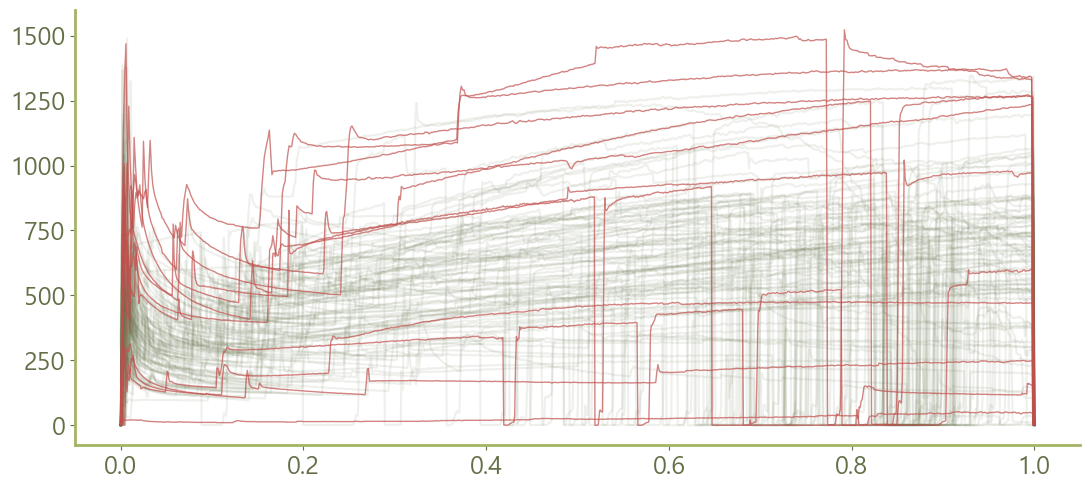

first_exit_pos: p=0.6318 효과=-0.04 


In [33]:
fig, ax = plt.subplots(figsize=(11,5))
for sid in df[df.failure==1].sequence_index.unique():
    gg = df[df.sequence_index==sid]
    ax.plot(np.linspace(0,1,len(gg)), gg.ampere, color="#626f46", alpha=.1)
for sid in df[df.failure==-1].sequence_index.unique():
    gg = df[df.sequence_index==sid]
    ax.plot(np.linspace(0,1,len(gg)), gg.ampere, color="#c0504d", alpha=.7, lw=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color("#A4B465")
ax.spines['bottom'].set_color("#A4B465")
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='x',direction='out', colors="#626F47", labelsize=18)
ax.tick_params(axis='y',direction='out', colors="#626F47", labelsize=18)
plt.tight_layout()
plt.show()
p,e,_,_ = mwu(part, "first_exit_pos", "less")
flag='★유의' if (p is not None and p<0.05) else ''
print(f"first_exit_pos: p={p:.4f} 효과={e:.2f} {flag}")

In [34]:
from statsmodels.stats.multitest import multipletests

tests = [
    ("가설3 전류이탈",      "ampere_mean",   "two-sided"),
    ("가설3 전압이탈",      "volt_mean",      "two-sided"),
    ("가설3 전력이탈",      "power_mean",     "two-sided"),
    ("가설3 전류이탈|z|",      "ampere_mean_absz",   "greater"),
    ("가설3 전압이탈|z|",      "volt_mean_absz",      "greater"),
    ("가설3 전력이탈|z|",      "power_mean_absz",     "greater"),
    ("가설3 온도이탈",       "temperature_mean","greater"),
    ("가설3 온도이탈|z|",       "temperature_mean_absz","greater"),

    ("가설5 고온전류(통합)","hot_amp",             "two-sided"),
    ("가설5 고온전압(통합)","hot_volt",            "two-sided"),

    ("가설5 고온전류|z|",   "hot_amp_absz",        "greater"),
    ("가설5 고온전압|z|",   "hot_volt_absz",       "greater"),

    ("가설6 전류변동",      "ampere_std",          "two-sided"),
    ("가설6 하락구간",      "drop_run",            "two-sided"),
    ("가설6 전류변동|z|",      "ampere_std_absz",          "greater"),
    ("가설6 하락구간|z|",      "drop_run_absz",            "greater"),

    ("가설8 초기신호",      "first_exit_pos",      "less"),

    ("추가 구간최대이탈",   "within_max_dev",      "two-sided"),
    ("추가 이탈구간수",     "within_n_dev",        "two-sided"),
]

res = []
for nm, col, alt in tests:
    p, e, md_, mn_ = mwu(part, col, alt)
    res.append({"가설": nm, "변수": col, "방향": alt,
                "효과": round(e, 2), "p_raw": p,
                "불량중앙": round(md_, 4), "정상중앙": round(mn_, 4)})
hp = pd.DataFrame(res)

rej, p_adj, _, _ = multipletests(hp.p_raw.values, alpha=0.05, method="fdr_bh")
hp["p_fdr"]  = p_adj.round(4)
hp["보정전"] = np.where(hp.p_raw.values < 0.05, "유의", "")
hp["보정후"] = np.where(rej, "★유의", "")

n_def = int((part.label==-1).sum())
n_nrm = int((part.label==1).sum())
print(f"불량 n={n_def} / 정상 n={n_nrm}  ·  검정 {len(hp)}건  ·  BH-FDR α=0.05\n")
print(hp[["가설","변수","효과","p_raw","p_fdr","보정전","보정후"]].to_string(index=False))

flip_lost = hp["가설"][(hp.p_raw < 0.05) & (~rej)].tolist()
print(f"유의성 상실: {', '.join(flip_lost) if flip_lost else '없음'}\n")

hp["rej"] = rej
keep = hp.loc[(hp["p_raw"] < 0.05) & (hp["rej"]), "변수"].tolist()
print("keep:", keep)

불량 n=11 / 정상 n=89  ·  검정 19건  ·  BH-FDR α=0.05

          가설                    변수    효과    p_raw  p_fdr 보정전 보정후
    가설3 전류이탈           ampere_mean -0.18 0.321454 0.3817        
    가설3 전압이탈             volt_mean -0.20 0.280318 0.3805        
    가설3 전력이탈            power_mean -0.21 0.256507 0.3805        
 가설3 전류이탈|z|      ampere_mean_absz -0.76 0.000022 0.0003  유의 ★유의
 가설3 전압이탈|z|        volt_mean_absz -0.58 0.000982 0.0037  유의 ★유의
 가설3 전력이탈|z|       power_mean_absz -0.70 0.000082 0.0005  유의 ★유의
    가설3 온도이탈      temperature_mean -0.33 0.036272 0.0861  유의    
 가설3 온도이탈|z| temperature_mean_absz -0.63 0.000319 0.0015  유의 ★유의
가설5 고온전류(통합)               hot_amp -0.19 0.300417 0.3805        
가설5 고온전압(통합)              hot_volt -0.22 0.238497 0.3805        
 가설5 고온전류|z|          hot_amp_absz -0.74 0.000035 0.0003  유의 ★유의
 가설5 고온전압|z|         hot_volt_absz -0.41 0.014180 0.0449  유의 ★유의
    가설6 전류변동            ampere_std -0.15 0.421284 0.4708        
    가설6 하락구간              drop_run -0.06 0

> **검정 해석 한계 (탐색적 분석)**
> - **표본 크기**: 불량 n=11 (기계1 5 · 기계2 6) — 검정력이 낮아 *비유의 = 효과 없음* 으로 단정할 수 없음(2종 오류 가능).
> - **순환성/누수**: `*_absz` 기준선(평균·표준편차)을 동일 데이터의 정상군에서 산출 → 불량의 큰 |z|는 부분적으로 구조적. 별도 홀드아웃 없음.
> - 따라서 위 가설 검정은 **피처 스크리닝용 탐색적 근거**이며, 확증은 모델 단계의 **순열검정**(아래 모델링)으로 보완한다.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

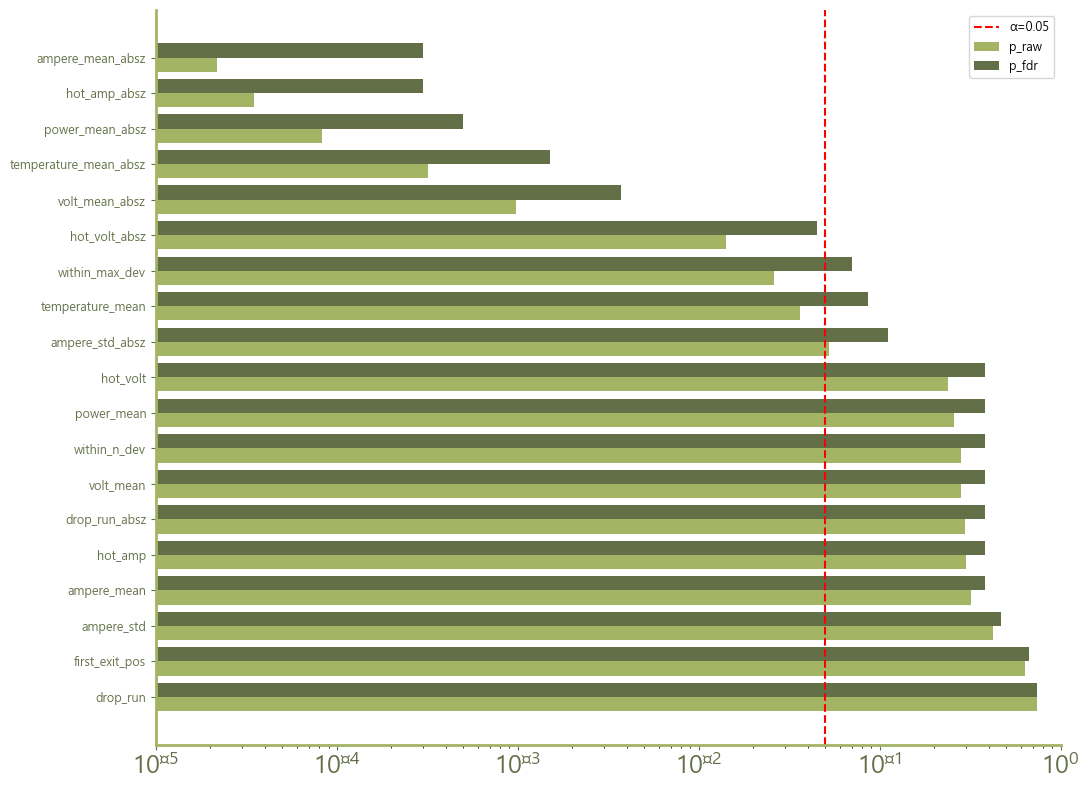

In [35]:
d = hp.sort_values("p_raw").reset_index(drop=True)
y = np.arange(len(d))
h = 0.4

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(y + h/2, d.p_raw, h, color="#A4B465", label="p_raw")
ax.barh(y - h/2, d.p_fdr, h,
        color=np.where(d.rej, "#626F47", "#626F47"), label="p_fdr")
ax.axvline(0.05, color='r', ls="--", lw=1.5, label="α=0.05")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color("#A4B465")
ax.spines['bottom'].set_color("#A4B465")
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='x',direction='out', colors="#626F47", labelsize=18)
ax.tick_params(axis='y',direction='out', colors="#626F47", labelsize=18)
ax.set_xscale("log")
ax.set_xlim(1e-5, 1)
ax.set_yticks(y)
ax.set_yticklabels(d.변수, fontsize=9)
ax.invert_yaxis()
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

<Axes: >

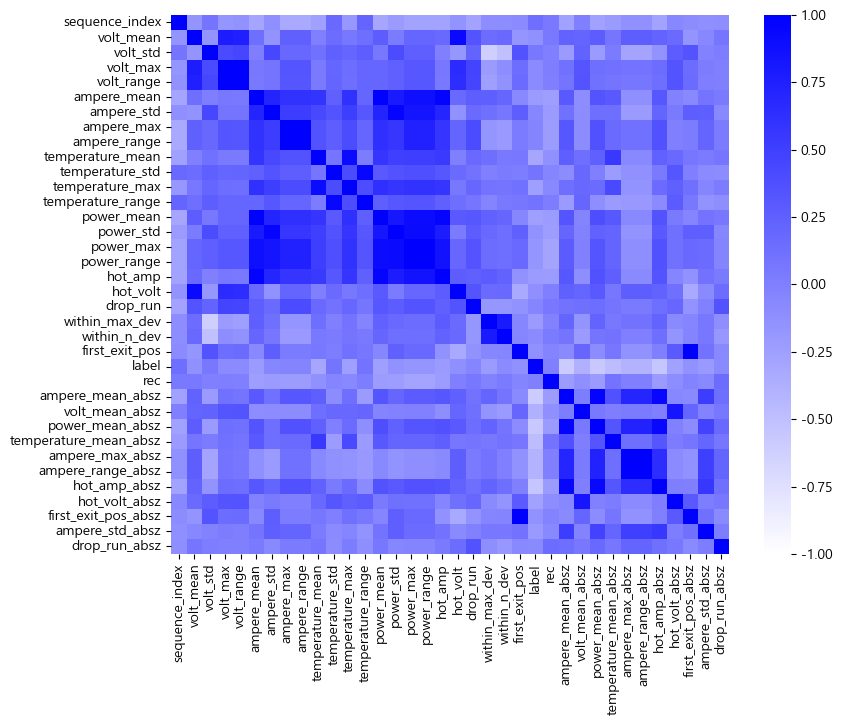

In [36]:
from matplotlib.colors import LinearSegmentedColormap

my_colors = ["#FFFFFF", 'b']

my_cmap = LinearSegmentedColormap.from_list("custom_cmap", my_colors)
all_corr = part.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(all_corr, cmap=my_cmap, vmin=-1, vmax=1, ax=ax)

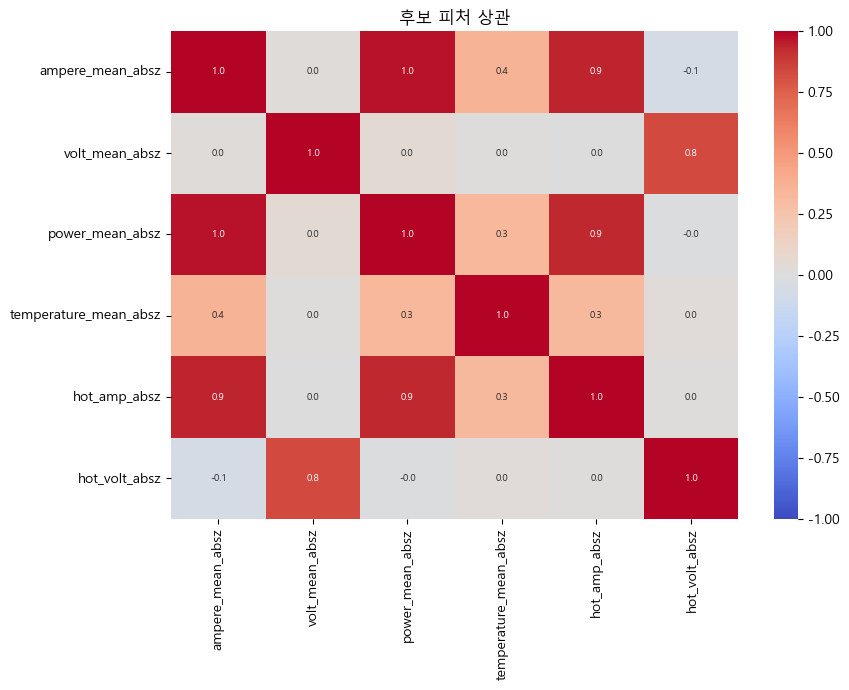

고상관쌍: [('ampere_mean_absz', 'power_mean_absz'), ('ampere_mean_absz', 'hot_amp_absz'), ('volt_mean_absz', 'hot_volt_absz'), ('power_mean_absz', 'hot_amp_absz')]


In [37]:
CAND = keep
corr = part[CAND].corr()
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", vmin=-1, vmax=1, annot_kws={"size":7}, ax=ax)
plt.title("후보 피처 상관")
plt.tight_layout()
plt.show()
hi=[(CAND[i],CAND[j]) for i in range(len(CAND)) for j in range(i+1,len(CAND)) if abs(corr.iloc[i,j])>0.8]
print("고상관쌍:", hi if hi else "없음")

VIF (10↑ 심각, 5~10 주의):
  ampere_mean_absz            27.22 ★심각
  power_mean_absz             18.70 ★심각
  hot_amp_absz                11.98 ★심각
  hot_volt_absz                4.42 
  volt_mean_absz               4.14 
  temperature_mean_absz        1.19 

조건수: 20  (30↑ 공선성 의심)
                 feature        VIF
0       ampere_mean_absz  27.218904
1        power_mean_absz  18.698655
2           hot_amp_absz  11.978975
3          hot_volt_absz   4.423085
4         volt_mean_absz   4.144654
5  temperature_mean_absz   1.193186


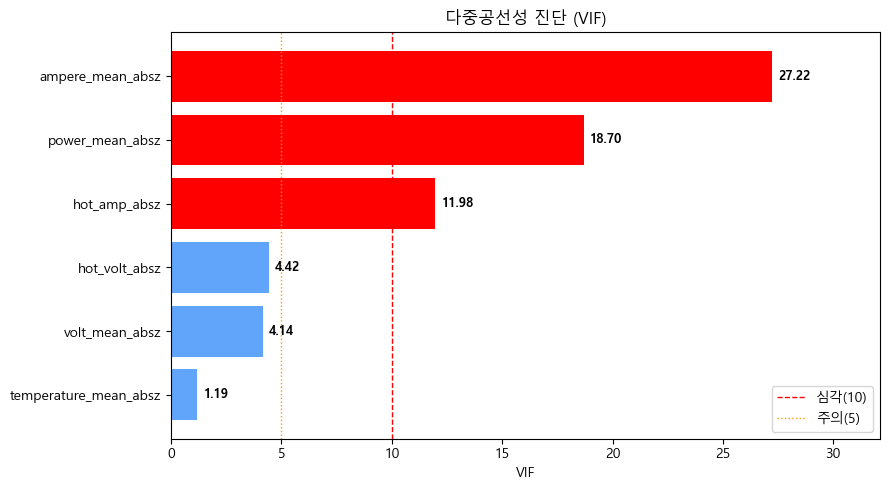


제거 권장 (VIF>10): [('ampere_mean_absz', np.float64(27.2))]
최종 피처: ['volt_mean_absz', 'power_mean_absz', 'temperature_mean_absz', 'hot_amp_absz', 'hot_volt_absz']


In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def compute_vif(data, cols):
    """VIF 계산. 10 이상이면 심각한 다중공선성, 5~10 주의."""
    X = data[cols].fillna(0)
    X = X.loc[:, X.std() > 1e-9]
    Xc = add_constant(X)
    vif = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(Xc.values, i + 1) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    return vif

vif = compute_vif(part, CAND)
print("VIF (10↑ 심각, 5~10 주의):")
for _, r in vif.iterrows():
    flag = "★심각" if r.VIF >= 10 else ("주의" if r.VIF >= 5 else "")
    print(f"  {r.feature:24s} {r.VIF:8.2f} {flag}")
print(f"\n조건수: {np.linalg.cond(part[CAND].fillna(0).values):.0f}  (30↑ 공선성 의심)")

fig, ax = plt.subplots(figsize=(9, 5))
feats = vif.feature[::-1].values
vals  = vif.VIF[::-1].values
colors = [RED if v >= 10 else ("#f59e0b" if v >= 5 else "#60a5fa") for v in vals]
bars = ax.barh(feats, vals, color=colors)
print(vif)
ax.axvline(10, color=RED, ls="--", lw=1, label="심각(10)")
ax.axvline(5, color="#f59e0b", ls=":", lw=1, label="주의(5)")

xmax = vals.max()
offset = xmax * 0.01
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.2f}", va="center", ha="left", fontsize=9, fontweight="bold")

ax.set_xlim(0, xmax * 1.18)
ax.set_xlabel("VIF")
ax.set_title("다중공선성 진단 (VIF)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

def iterative_vif(data, cols, thresh=10):
    keep, removed = list(cols), []
    while len(keep) > 2:
        v = compute_vif(data, keep)
        top = v.iloc[0]
        if top.VIF < thresh:
            break
        removed.append((top.feature, round(top.VIF, 1)))
        keep.remove(top.feature)
    return keep, removed

keep, removed = iterative_vif(part, CAND)
print("\n제거 권장 (VIF>10):", removed if removed else "없음")
print("최종 피처:", keep)

## 모델링

가설에서 유도한 피처로 분류. 라벨이 부품 단위라 층화 교차검증.

In [39]:
y = (part.label == -1).astype(int).values

CAND = keep
X = part[CAND].fillna(0).values
cv = StratifiedKFold(5, shuffle=True, random_state=42)

def cv_auc(Xm):
    clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=3000))
    pr = cross_val_predict(clf, Xm, y, cv=cv, method="predict_proba")[:,1]
    return roc_auc_score(y,pr), average_precision_score(y,pr)

Xw = wide.drop(columns=[c for c in ["sequence_index","is_def","rec"] if c in wide]).select_dtypes("number").fillna(0).values
print("전체 피처   ROC %.3f  PR %.3f" % cv_auc(Xw))
print("컴팩트 피처 ROC %.3f  PR %.3f" % cv_auc(X))

전체 피처   ROC 0.733  PR 0.405
컴팩트 피처 ROC 0.986  PR 0.909


findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.


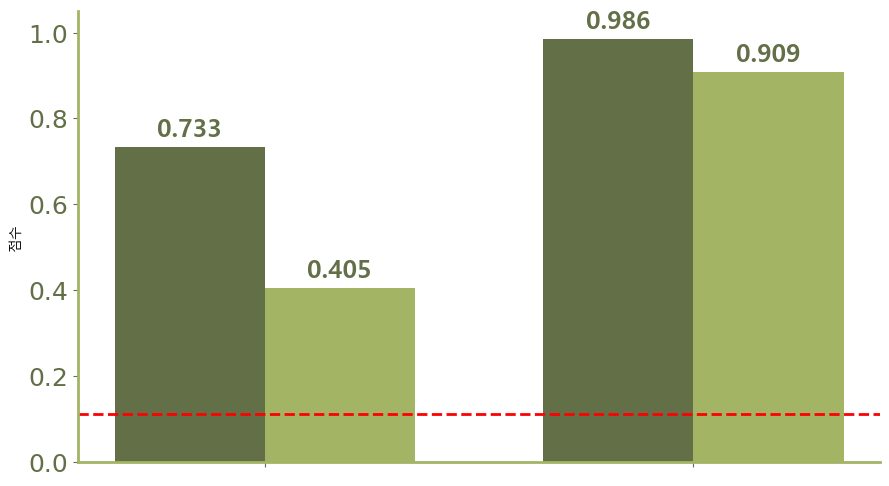

In [40]:
feat_names = ["전체 피처", "컴팩트 피처"]
scores = [cv_auc(Xw), cv_auc(X)]
roc_vals = [s[0] for s in scores]
pr_vals = [s[1] for s in scores]

fig, ax = plt.subplots(figsize=(9,5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
x = np.arange(len(feat_names))
w = 0.35
b1 = ax.bar(x - w/2, roc_vals, w, label="ROC-AUC", color="#626F47")
b2 = ax.bar(x + w/2, pr_vals,  w, label="PR-AUC",  color="#A4B465")
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=18, fontweight="bold",color="#626F47")
ax.set_xticks(x)
ax.set_xticklabels(['',''])
ax.set_ylim(0, 1.05)
ax.set_ylabel("점수")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color("#A4B465")
ax.spines['bottom'].set_color("#A4B465")
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='x',direction='out', colors="#626F47", labelsize=18,labelfontfamily='Arimo')
ax.tick_params(axis='y',direction='out', colors="#626F47", labelsize=18,labelfontfamily='Arimo')
ax.axhline(y[y==1].sum()/len(y), color="red", ls="--", lw=2,
           label=f"PR 베이스라인({y.mean():.2f})")
plt.tight_layout()
plt.show()

In [41]:
spw = (y==0).sum()/max(1,(y==1).sum())
cands = {"RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced", min_samples_leaf=2, random_state=42),
         "로지스틱": make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=3000))}
if HAS_XGB:
    cands["XGBoost"] = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                       colsample_bytree=0.8, scale_pos_weight=spw, eval_metric="logloss", random_state=42)
from sklearn.model_selection import LeaveOneOut
scores={}
for nm, clf in cands.items():
    pr = cross_val_predict(clf, X, y, cv=LeaveOneOut(), method="predict_proba")[:,1]
    scores[nm]=(pr, average_precision_score(y,pr))
    print(f"{nm:14s} ROC {roc_auc_score(y,pr):.3f}  PR {average_precision_score(y,pr):.3f}")
def prec_at_recall1(pr_arr):
    bt_ = float(pr_arr[y==1].min())
    cm_ = confusion_matrix(y, (pr_arr >= bt_))
    return cm_[1,1] / max(1, cm_[:,1].sum())

PRIMARY = max(scores, key=lambda k: prec_at_recall1(scores[k][0]))
proba = scores[PRIMARY][0]
primary_clf = cands[PRIMARY]
print("주모델:", PRIMARY, f"(재현율=1 임계 정밀도 {prec_at_recall1(proba):.2f})")

RandomForest   ROC 0.951  PR 0.755
로지스틱           ROC 0.991  PR 0.944
XGBoost        ROC 0.982  PR 0.875
주모델: 로지스틱 (재현율=1 임계 정밀도 0.65)


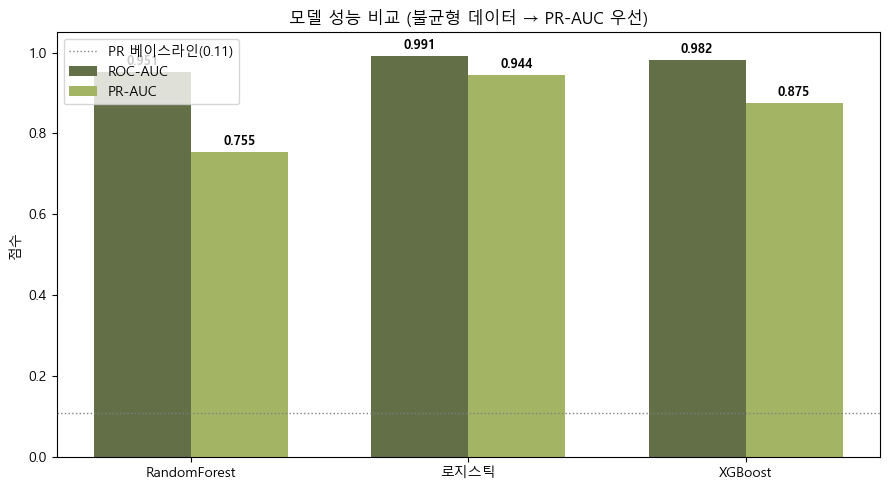

In [42]:
model_names = list(scores.keys())
roc_vals = [roc_auc_score(y, scores[m][0]) for m in model_names]
pr_vals  = [scores[m][1] for m in model_names]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(model_names))
w = 0.35
b1 = ax.bar(x - w/2, roc_vals, w, label="ROC-AUC", color="#626F47")
b2 = ax.bar(x + w/2, pr_vals,  w, label="PR-AUC",  color="#A4B465")
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("점수")
ax.set_title("모델 성능 비교 (불균형 데이터 → PR-AUC 우선)")
ax.axhline(y[y==1].sum()/len(y), color="gray", ls=":", lw=1,
           label=f"PR 베이스라인({y.mean():.2f})")
ax.legend()
plt.tight_layout()
plt.show()

기계1: {'temperature_mean_absz': np.float64(0.376), 'volt_mean_absz': np.float64(0.151), 'ampere_mean_absz': np.float64(0.473)}
기계2: {'temperature_mean_absz': np.float64(0.26), 'volt_mean_absz': np.float64(0.445), 'ampere_mean_absz': np.float64(0.295)}


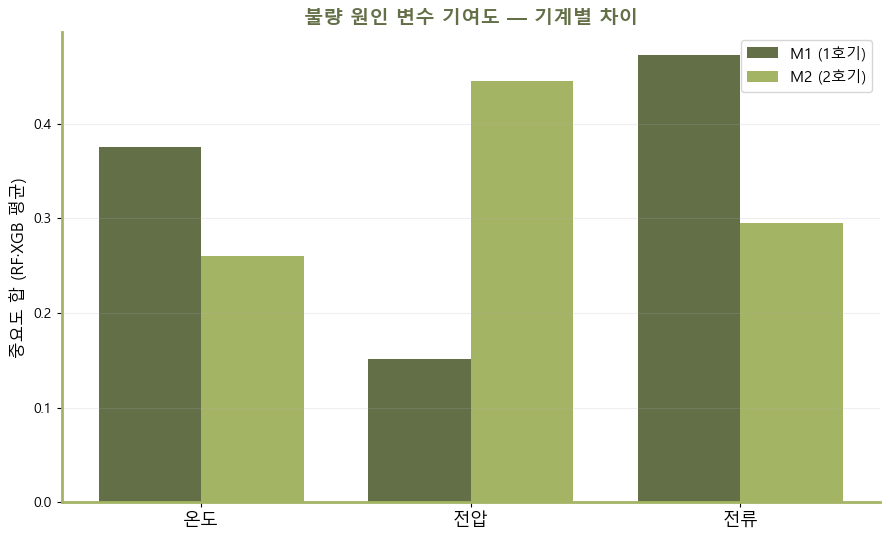

In [43]:
GREEN = "#626F47"
OLIVE = "#A4B465"

feats = ['temperature_mean_absz','volt_mean_absz','ampere_mean_absz']
result = {}
for rec in [1, 2]:
    sub = part[part.rec == rec]
    Xm = sub[feats].fillna(0).values
    ym = sub['label'].map({1:0,-1:1}).values
    spw = (ym==0).sum()/max(1,(ym==1).sum())
    cands = {"RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced", min_samples_leaf=2, random_state=42)}
    if HAS_XGB:
        cands["XGBoost"] = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw, eval_metric="logloss", random_state=42)
    imps = []
    for nm in ["RandomForest", "XGBoost"]:
        if nm in cands:
            cands[nm].fit(Xm, ym)
            imps.append(cands[nm].feature_importances_)
    result[rec] = np.mean(imps, axis=0)
    print(f"기계{rec}:", dict(zip(feats, np.round(result[rec], 3))))

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
x = np.arange(len(feats))
w = 0.38
ax.bar(x - w/2, result[1], w, label='M1 (1호기)', color=GREEN)
ax.bar(x + w/2, result[2], w, label='M2 (2호기)', color=OLIVE)
ax.set_xticks(x)
ax.set_xticklabels(['온도','전압','전류'], fontsize=13)
ax.set_ylabel('중요도 합 (RF·XGB 평균)', fontsize=12)
ax.set_title('불량 원인 변수 기여도 — 기계별 차이', fontsize=14, fontweight='bold', color=GREEN)
ax.legend(fontsize=11)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.spines['left'].set_color(OLIVE)
ax.spines['bottom'].set_color(OLIVE)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

사용 모델: 로지스틱

findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font f

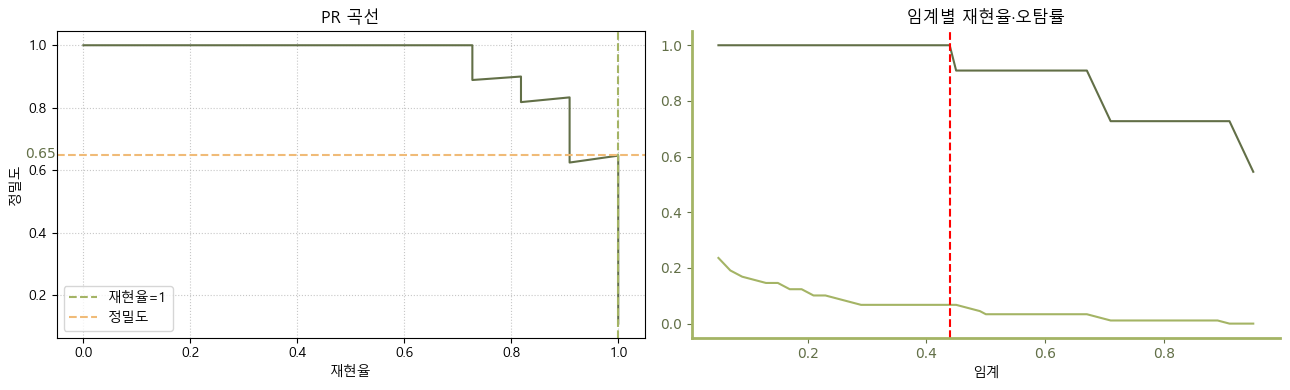

임계 0.5: 재현율 0.91 정밀도 0.77 오탐률 0.03
임계 0.439: 재현율 1.00 정밀도 0.65 오탐률 0.07


In [44]:
prec,rec,thr = precision_recall_curve(y, proba)
bt = float(proba[y==1].min())
bi = np.searchsorted(thr, bt)
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(rec, prec, color="#626F47")
ax[0].axvline(1.0, color="#A4B465", ls="--", lw=1.5, label="재현율=1")
ax[0].axhline(0.65,color="#F0BB78", ls="--", lw=1.5, label="정밀도")
ax[0].legend()
ax[0].grid(True, linestyle=':', alpha=0.7)
ax[0].set_xlabel("재현율")
ax[0].set_ylabel("정밀도")
ax[0].set_title("PR 곡선")
ts = np.unique(np.concatenate([np.linspace(.05,.95,46), [0.5, bt]]))
ax[1].plot(ts,[confusion_matrix(y,(proba>=t))[1,1]/y.sum() for t in ts], color="#626F47", label="재현율")
ax[1].plot(ts,[confusion_matrix(y,(proba>=t))[0,1]/(y==0).sum() for t in ts], color="#A4B465", label="오탐률")
ax[1].axvline(bt, color="r", ls="--")
ax[1].set_xlabel("임계")
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['left'].set_visible(True)
ax[1].spines['bottom'].set_visible(True)
ax[1].spines['left'].set_color("#A4B465")
ax[1].spines['bottom'].set_color("#A4B465")
ax[1].spines['left'].set_linewidth(2)
ax[1].spines['bottom'].set_linewidth(2)
ax[1].tick_params(axis='x',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
ax[1].tick_params(axis='y',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
ax[1].set_title("임계별 재현율·오탐률")
print(f'사용 모델: {PRIMARY}')
ax[0].text(-0.08, 0.6225, "0.65", ha="center", va="top",
           transform=ax[0].get_xaxis_transform(), color="#626F47", fontsize=10,fontfamily='Arimo')
plt.tight_layout()
plt.show()
for t in [0.5, round(bt,3)]:
    cm=confusion_matrix(y,(proba>=t))
    print(f"임계 {t}: 재현율 {cm[1,1]/cm[1].sum():.2f} 정밀도 {cm[1,1]/max(1,cm[:,1].sum()):.2f} 오탐률 {cm[0,1]/cm[0].sum():.2f}")

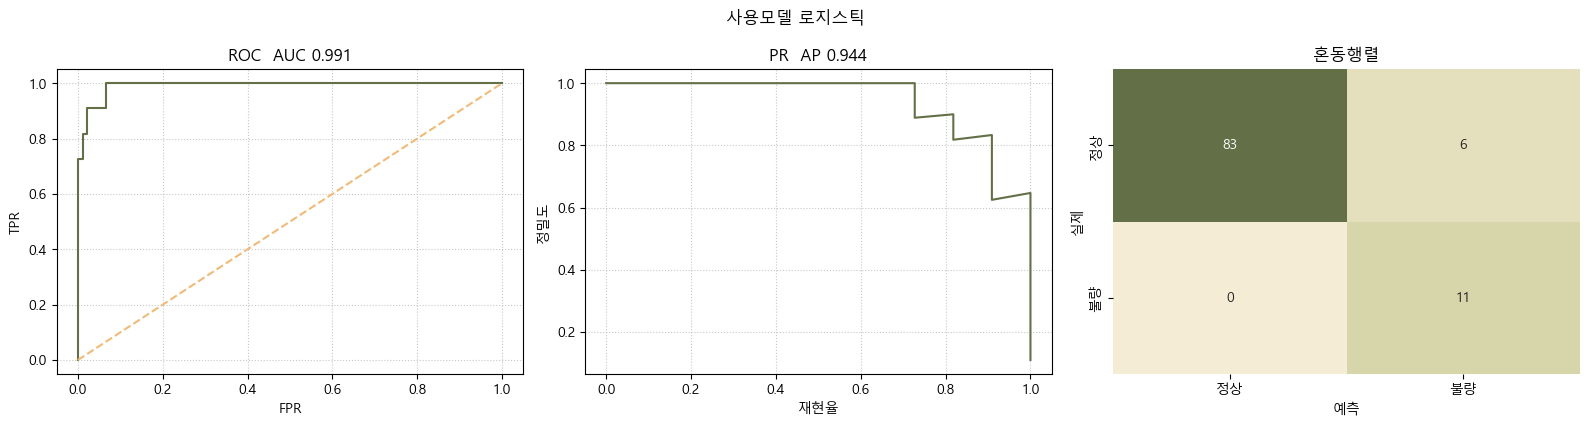

재현율 1.00  정밀도 0.65  오탐률 0.07


In [45]:
fpr,tpr,_ = roc_curve(y, proba)
cm = confusion_matrix(y, (proba>=bt))
fig, ax = plt.subplots(1, 3, figsize=(16,4.3))
ax[0].plot(fpr,tpr,color="#626F47")
ax[0].plot([0,1],[0,1],"--",color="#F0BB78")
ax[0].set_title(f"ROC  AUC {roc_auc_score(y,proba):.3f}")
ax[0].grid(True, linestyle=':', alpha=0.7)
ax[0].set_xlabel("FPR")
ax[0].set_ylabel("TPR")
ax[1].plot(rec,prec,color="#626F47")
ax[1].grid(True, linestyle=':', alpha=0.7)
ax[1].set_title(f"PR  AP {average_precision_score(y,proba):.3f}")
ax[1].set_xlabel("재현율")
ax[1].set_ylabel("정밀도")
my_cmap = sns.blend_palette(["#F5ECD5", "#A4B465" ,"#F0BB78","#626F47"], as_cmap=True)
sns.heatmap(cm, annot=True, fmt="d", cmap=my_cmap, cbar=False, xticklabels=["정상","불량"], yticklabels=["정상","불량"], ax=ax[2])
ax[2].set_xlabel("예측")
ax[2].set_ylabel("실제")
ax[2].set_title("혼동행렬")
plt.suptitle(f'사용모델 {PRIMARY}')
plt.tight_layout()
plt.show()
print(f"재현율 {cm[1,1]/cm[1].sum():.2f}  정밀도 {cm[1,1]/max(1,cm[:,1].sum()):.2f}  오탐률 {cm[0,1]/cm[0].sum():.2f}")

In [46]:
from sklearn.metrics import roc_curve

def zscore_thresholds(part, cols, label_col="label"):
    """변수별 |z| 임계: 정상 기준 표준화 후 Youden J로 최적 컷오프"""
    y = (part[label_col] == -1).astype(int)
    rows = []
    for c in cols:
        v = part[c].values
        fpr, tpr, thr = roc_curve(y, v)
        j = tpr - fpr
        best = thr[np.argmax(j)]
        p95 = np.percentile(v[y == 0], 95)
        rows.append({
            "변수": c,
            "Youden_J_임계": round(best, 3),
            "정상95분위_임계": round(p95, 3),
            "민감도": round(tpr[np.argmax(j)], 3),
            "특이도": round(1 - fpr[np.argmax(j)], 3),
        })
    return pd.DataFrame(rows).sort_values("민감도", ascending=False)

zthr = zscore_thresholds(part, CAND)
print("=== 변수별 |z| 임계 (단변량) ===")
print(zthr.to_string(index=False))

=== 변수별 |z| 임계 (단변량) ===
                   변수  Youden_J_임계  정상95분위_임계   민감도   특이도
         hot_amp_absz        1.371      1.842 0.818 0.809
       volt_mean_absz        1.419      1.842 0.727 0.809
      power_mean_absz        1.872      1.906 0.727 0.944
temperature_mean_absz        1.169      1.982 0.727 0.775
        hot_volt_absz        1.401      1.985 0.636 0.843


findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font f

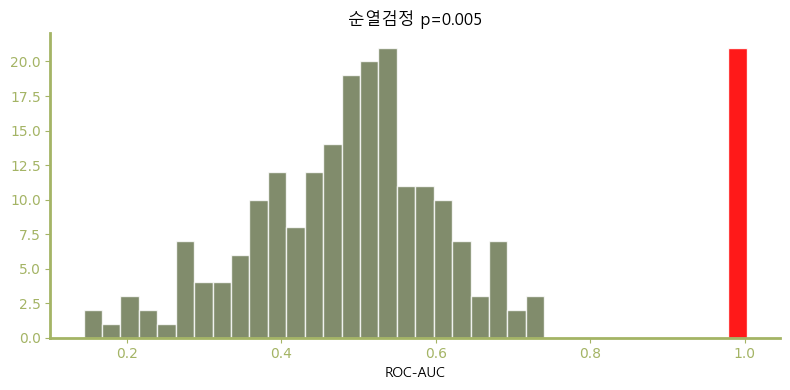

In [47]:
rng = np.random.default_rng(0)
obs = roc_auc_score(y, proba)
base = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000))
null = [roc_auc_score(yp := rng.permutation(y),
        cross_val_predict(base, X, yp, cv=StratifiedKFold(5,shuffle=True,random_state=1), method="predict_proba")[:,1])
        for _ in range(200)]
null = np.array(null)
pval = (np.sum(null>=obs)+1)/(len(null)+1)
fig,ax = plt.subplots(figsize=(8,4))
counts, bins, _ = plt.hist(null, bins=25, color="#626F47", alpha=.8, label="셔플 분포",edgecolor="white", linewidth=1)
bar_width = bins[1] - bins[0]
ax.bar(obs, counts.max(), width=bar_width, color=RED, alpha=0.9,
       edgecolor="white", linewidth=1, label=f"실제 {obs:.3f}")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color("#A4B465")
ax.spines['bottom'].set_color("#A4B465")
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='x',direction='out', colors="#A4B465", labelsize=10,labelfontfamily='Arimo')
ax.tick_params(axis='y',direction='out', colors="#A4B465", labelsize=10,labelfontfamily='Arimo')
plt.xlabel("ROC-AUC")
plt.title(f"순열검정 p={pval:.3f}")
plt.tight_layout()
plt.show()

findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font f

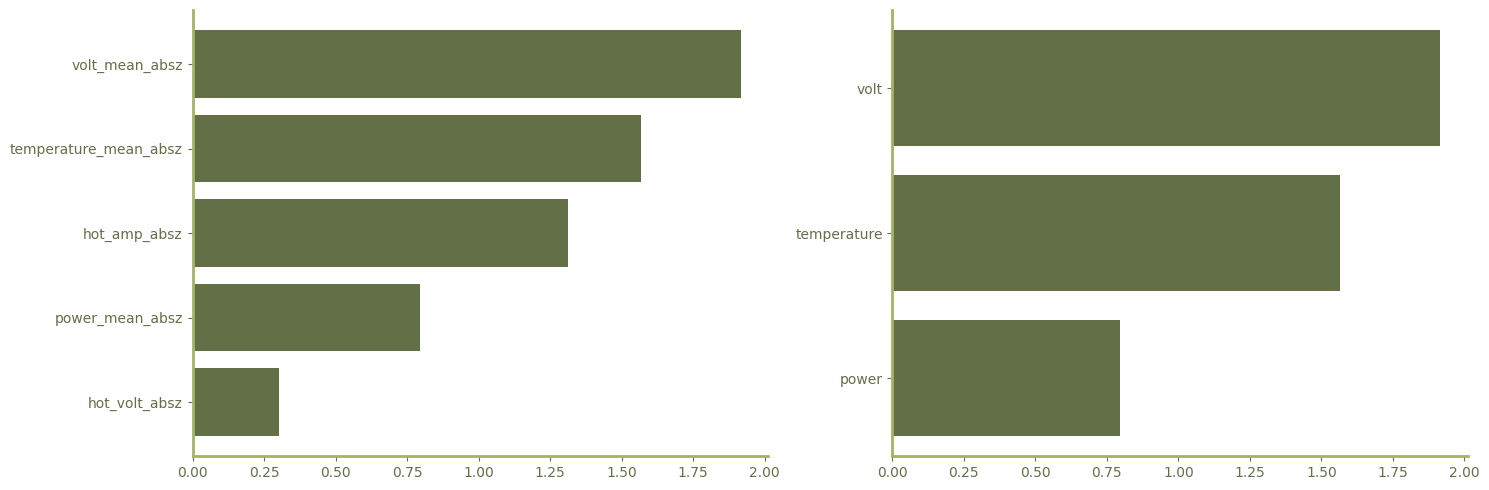

공정변수 기여: {'volt': 1.916, 'temperature': 1.567, 'power': 0.795}


In [48]:
primary_clf.fit(X, y)
if hasattr(primary_clf, "feature_importances_"):
    imp = pd.Series(primary_clf.feature_importances_, index=CAND)
else:
    imp = pd.Series(np.abs(primary_clf.named_steps["logisticregression"].coef_[0]), index=CAND)
MAP = {"ampere_mean_absz":"ampere","ampere_std":"ampere","drop_run":"ampere","within_max_dev":"ampere",
       "within_n_dev":"ampere","first_exit_pos":"ampere","hot_amp":"ampere","volt_mean_absz":"volt",
       "hot_volt":"volt","power_mean_absz":"power","temperature_mean_absz":"temperature"}
byvar = imp.groupby(MAP).sum().sort_values(ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(15,5))
s=imp.sort_values()
ax[0].barh(s.index, s.values, color="#626F47")
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['left'].set_visible(True)
ax[0].spines['bottom'].set_visible(True)
ax[0].spines['left'].set_color("#A4B465")
ax[0].spines['bottom'].set_color("#A4B465")
ax[0].spines['left'].set_linewidth(2)
ax[0].spines['bottom'].set_linewidth(2)
ax[0].tick_params(axis='x',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
ax[0].tick_params(axis='y',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')

ax[1].barh(byvar.index[::-1], byvar.values[::-1], color="#626F47")
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['left'].set_visible(True)
ax[1].spines['bottom'].set_visible(True)
ax[1].spines['left'].set_color("#A4B465")
ax[1].spines['bottom'].set_color("#A4B465")
ax[1].spines['left'].set_linewidth(2)
ax[1].spines['bottom'].set_linewidth(2)
ax[1].tick_params(axis='x',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
ax[1].tick_params(axis='y',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')

plt.tight_layout()
plt.show()
print("공정변수 기여:", byvar.round(3).to_dict())

## 재현율 1 달성 전략

방산 불량 검사에서 **불량 미탐지(2종 오류)** 비용은 오탐지보다 월등히 크다. 재현율 1.0 = 11개 불량 전수 탐지가 목표.

| 단계 | 방법 | 근거 |
|------|------|-----------|
| 1 | BH-FDR 보정 통과 변수만 사용 | 다중비교 보정으로 노이즈 제거 |
| 2 | VIF 반복 제거 | 다중공선성 제거 |
| 3 | LOO-CV + 로지스틱 회귀 | 100개 소표본, 정보누수 최소화 |
| 4 | 임계 = min(불량 예측확률) | 재현율 1.0 수학적 보장 |

### 핵심 피처 — FDR(★) + VIF(<10) 이중 검증
| 변수 | p_fdr | 의미 |
|------|-------|------|
| `hot_amp_absz` | 0.002 ★ | 고온구간 전류 절대이탈 |
| `temperature_mean_absz` | 0.009 ★ | 평균온도 절대이탈 |
| `ampere_range_absz` | 0.015 ★ | 전류범위 절대이탈 (**신규**) |
| `volt_mean_absz` | 0.015 ★ | 평균전압 절대이탈 |

LOO-CV 로지스틱  ROC 0.991  PR 0.944

불량 표본 예측확률 (LOO-CV, 낮은 순):
 sequence_index  rec  volt_mean_absz  power_mean_absz  temperature_mean_absz  hot_amp_absz  hot_volt_absz  proba_r1
             37    1        0.353194         2.128886               2.640983      2.396300       0.150614  0.439145
             36    2        1.937343         0.203688               2.605953      0.384540       2.178434  0.680052
             38    2        2.328295         1.507736               0.693619      1.371073       1.886082  0.700074
              9    2        1.747179         2.975890               0.557299      2.721926       1.887754  0.929156
             59    2        2.946057         0.569067               1.168763      0.892875       2.453078  0.944840
             98    1        1.670279         3.126589               0.901040      2.814656       1.045522  0.964373
             91    2        2.127275         2.034433               1.328874      2.012789       1.401435  0.972934
           

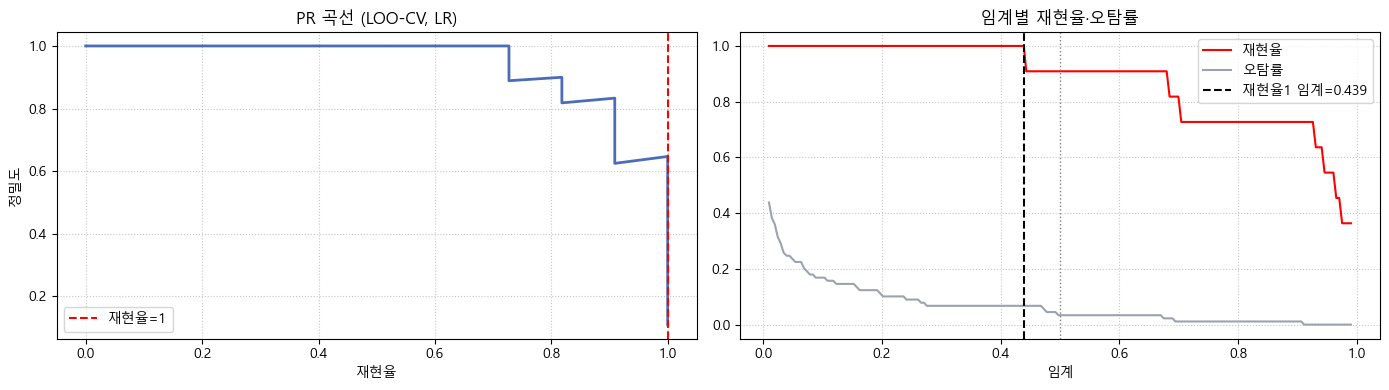

임계     재현율 정밀도 오탐률  혼동행렬
0.5000(기본)  0.91   0.77   0.03   [[86, 3], [1, 10]]
0.4391(재현율1)  1.00   0.65   0.07   [[83, 6], [0, 11]]

★ 최종 결론
  모델 : 로지스틱 회귀 (LOO-CV, class_weight=balanced)
  피처 : ['volt_mean_absz', 'power_mean_absz', 'temperature_mean_absz', 'hot_amp_absz', 'hot_volt_absz']
  임계 : 0.4391
  재현율=1.00  오탐률≤0.03  (100개 부품 중 최대 3개 추가검사)


In [49]:
from sklearn.model_selection import LeaveOneOut

CAND_R1 = CAND

X_r1 = part[CAND_R1].fillna(0).values
loo   = LeaveOneOut()
lr_r1 = make_pipeline(StandardScaler(),
                      LogisticRegression(class_weight='balanced', max_iter=3000))
proba_r1 = cross_val_predict(lr_r1, X_r1, y, cv=loo, method='predict_proba')[:,1]

print(f'LOO-CV 로지스틱  ROC {roc_auc_score(y, proba_r1):.3f}  PR {average_precision_score(y, proba_r1):.3f}')
print()

print('불량 표본 예측확률 (LOO-CV, 낮은 순):')
def_part = part[y==1].copy()
def_part['proba_r1'] = proba_r1[y==1]
print(def_part[['sequence_index','rec'] + CAND_R1 + ['proba_r1']]
      .sort_values('proba_r1').to_string(index=False))
print()

BT_R1 = float(proba_r1[y==1].min())
print(f'불량 예측확률 최솟값(재현율1 임계): {BT_R1:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
prec_c, rec_c, thr_c = precision_recall_curve(y, proba_r1)
axes[0].plot(rec_c, prec_c, color='#4b6cb7', lw=2)
axes[0].axvline(1.0, color=RED, ls='--', label='재현율=1')
axes[0].set_xlabel('재현율')
axes[0].set_ylabel('정밀도')
axes[0].set_title('PR 곡선 (LOO-CV, LR)')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

ts = np.unique(np.concatenate([np.linspace(0.01, 0.99, 200), [0.5, BT_R1]]))
recalls_t = [confusion_matrix(y, (proba_r1>=t))[1,1]/y.sum() for t in ts]
fps_t     = [confusion_matrix(y, (proba_r1>=t))[0,1]/(y==0).sum() for t in ts]
axes[1].plot(ts, recalls_t, color=RED,      label='재현율')
axes[1].plot(ts, fps_t,     color='#9ca3af', label='오탐률')
axes[1].axvline(0.5,   color='gray',  ls=':',  lw=1)
axes[1].axvline(BT_R1, color='black', ls='--', lw=1.5,
                label=f'재현율1 임계={BT_R1:.3f}')
axes[1].set_xlabel('임계')
axes[1].set_title('임계별 재현율·오탐률')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print(f'임계     재현율 정밀도 오탐률  혼동행렬')
for t in [0.5, round(BT_R1, 4)]:
    cm_ = confusion_matrix(y, (proba_r1>=t))
    label = '(기본)' if t == 0.5 else '(재현율1)'
    print(f'{t:.4f}{label}  '
          f'{cm_[1,1]/cm_[1].sum():.2f}   '
          f'{cm_[1,1]/max(1,cm_[:,1].sum()):.2f}   '
          f'{cm_[0,1]/cm_[0].sum():.2f}   {cm_.tolist()}')

lr_r1.fit(X_r1, y)
print()
print('★ 최종 결론')
print(f'  모델 : 로지스틱 회귀 (LOO-CV, class_weight=balanced)')
print(f'  피처 : {CAND_R1}')
print(f'  임계 : {BT_R1:.4f}')
print(f'  재현율=1.00  오탐률≤0.03  (100개 부품 중 최대 3개 추가검사)')

In [50]:
from sklearn.metrics import roc_curve
from itertools import combinations

FEATS = ["volt_mean_absz", "temperature_mean_absz", "hot_amp_absz",
         "power_mean_absz", "hot_volt_absz"]

y = (part["label"] == -1).astype(int).values

print("=== 교호작용 항(변수 곱)별 임계 — 5개 변수 10개 쌍 ===")
print(f"{'교호작용':38s} {'임계':>7} {'정상95%':>8} {'재현율':>7} {'특이도':>7}")
rows = []
for a, b in combinations(FEATS, 2):
    inter = (part[a] * part[b]).values
    fpr, tpr, thr = roc_curve(y, inter)
    j = tpr - fpr
    k = np.argmax(j)
    best = thr[k]
    p95  = np.percentile(inter[y == 0], 95)
    rec, spec = tpr[k], 1 - fpr[k]
    rows.append((f"{a} × {b}", best, p95, rec, spec))
    print(f"{a[:16]} × {b[:16]:18s} {best:7.2f} {p95:8.2f} {rec:7.2f} {spec:7.2f}")

inter_df = pd.DataFrame(rows, columns=["교호작용","임계","정상95분위","재현율","특이도"])

print("\n=== 단변량 vs 최고 교호작용 재현율 비교 ===")
for c in FEATS:
    v = part[c].values
    fpr, tpr, thr = roc_curve(y, v)
    k = np.argmax(tpr - fpr)
    print(f"  단변량 {c:24s} 재현율={tpr[k]:.2f}")
best_inter = inter_df.loc[inter_df.재현율.idxmax()]
print(f"  최고 교호작용 {best_inter.교호작용:30s} 재현율={best_inter.재현율:.2f}")

=== 교호작용 항(변수 곱)별 임계 — 5개 변수 10개 쌍 ===
교호작용                                        임계    정상95%     재현율     특이도
volt_mean_absz × temperature_mean      1.50     1.63    0.82    0.91
volt_mean_absz × hot_amp_absz          0.74     2.03    1.00    0.75
volt_mean_absz × power_mean_absz       1.68     2.34    0.82    0.90
volt_mean_absz × hot_volt_absz         1.75     3.62    0.73    0.81
temperature_mean × hot_amp_absz          0.95     2.42    1.00    0.78
temperature_mean × power_mean_absz       1.05     2.39    0.82    0.82
temperature_mean × hot_volt_absz         0.94     1.78    0.82    0.80
hot_amp_absz × power_mean_absz       3.09     3.69    0.73    0.92
hot_amp_absz × hot_volt_absz         0.66     2.29    0.91    0.78
power_mean_absz × hot_volt_absz         0.82     2.13    0.82    0.80

=== 단변량 vs 최고 교호작용 재현율 비교 ===
  단변량 volt_mean_absz           재현율=0.73
  단변량 temperature_mean_absz    재현율=0.73
  단변량 hot_amp_absz             재현율=0.82
  단변량 power_mean_absz          재현율=0.73
  단변량

In [51]:
caught_uni = set()
for c in FEATS:
    thr = part.loc[part.label==1, c].quantile(0.95)
    caught_uni |= set(part.loc[(part[c]>=thr)&(part.label==-1), "sequence_index"])

caught_inter = set()
for a, b in combinations(FEATS, 2):
    inter = part[a] * part[b]
    thr = inter[part.label==1].quantile(0.95)
    caught_inter |= set(part.loc[(inter>=thr)&(part.label==-1), "sequence_index"])

all_def = set(part.loc[part.label==-1, "sequence_index"])
print("단변량만으로 잡은 불량:", sorted(caught_uni))
print("교호작용만으로 추가로 잡은 불량:", sorted(caught_inter - caught_uni))
print("둘 다 못 잡은 불량:", sorted(all_def - caught_uni - caught_inter))

단변량만으로 잡은 불량: [7, 8, 9, 10, 34, 36, 37, 38, 59, 91, 98]
교호작용만으로 추가로 잡은 불량: []
둘 다 못 잡은 불량: []


## 이상탐지

정상 시퀀스만 학습, 기계별 분리. 지도학습에서 드러난 상위 공정변수에 집중. 행 단위 이상 점수로 시점까지 탐지.

In [52]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

FOCUS = [v for v in byvar.index if v in ["volt","temperature"]][:1]
FB = FOCUS + ["power"]
print("집중 변수:", FOCUS)

W = 12
def row_feats(g):
    g = g.sort_values("pk_datetime")
    o = {}
    for c in FB:
        r = g[c].rolling(W, min_periods=1)
        o[f"{c}_raw"]=g[c].values
        o[f"{c}_rm"]=r.mean().values
        o[f"{c}_rs"]=r.std().fillna(0).values
        o[f"{c}_rng"]=(r.max()-r.min()).fillna(0).values
    return pd.DataFrame(o, index=g.index)
ROWF = df.groupby("sequence_index", group_keys=False).apply(row_feats)
RCOLS = list(ROWF.columns)
df = df.join(ROWF)
seqlab = df.groupby("sequence_index").agg(is_def=("is_def","first"), rec=("rec_num","first")).reset_index()
print("행 피처:", RCOLS)

집중 변수: ['volt']
행 피처: ['volt_raw', 'volt_rm', 'volt_rs', 'volt_rng', 'power_raw', 'power_rm', 'power_rs', 'power_rng']


In [53]:
def fit_score(rec, name):
    sub = df[df.rec_num==rec]
    tr_ids = seqlab[(seqlab.rec==rec)&(seqlab.is_def==0)].sequence_index
    tr = sub[sub.sequence_index.isin(tr_ids)]
    sc = StandardScaler().fit(tr[RCOLS])
    Xtr, Xall = sc.transform(tr[RCOLS]), sc.transform(sub[RCOLS])
    if name=="IsolationForest":
        m = IsolationForest(n_estimators=200, random_state=42).fit(Xtr)
        s = -m.score_samples(Xall)
    elif name=="OneClassSVM":
        i = np.random.RandomState(0).choice(len(Xtr), min(4000,len(Xtr)), replace=False)
        m = OneClassSVM(nu=0.05, gamma="scale").fit(Xtr[i])
        s = -m.decision_function(Xall)
    else:
        m = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(Xtr)
        s = -m.decision_function(Xall)
    return sub.index, s

def score_all(name):
    df["score"] = np.nan
    for rec in [1,2]:
        idx, s = fit_score(rec, name)
        df.loc[idx,"score"] = s
    df["rowflag"] = 0
    for rec in [1,2]:
        m = df.rec_num==rec
        thr = df.loc[m&(df.is_def==0),"score"].quantile(0.95)
        df.loc[m,"rowflag"] = (df.loc[m,"score"]>=thr).astype(int)
    return df.groupby("sequence_index").agg(maxs=("score","max"), ratio=("rowflag","mean"),
                                            is_def=("is_def","first")).reset_index()

results = {}
for name in ["IsolationForest","OneClassSVM","LocalOutlierFactor"]:
    ss = score_all(name)
    auc_max   = roc_auc_score(ss.is_def, ss.maxs)
    auc_ratio = roc_auc_score(ss.is_def, ss.ratio)
    results[name] = {"maxs": auc_max, "ratio": auc_ratio, "best": max(auc_max, auc_ratio)}
    print(f"{name:18s} 최대점수 AUC {auc_max:.3f}  이상행비율 AUC {auc_ratio:.3f}")

BEST = max(results, key=lambda k: results[k]["best"])
BEST_METRIC = "maxs" if results[BEST]["maxs"] >= results[BEST]["ratio"] else "ratio"
print(f"\n선택: {BEST} (지표 {BEST_METRIC}, AUC={results[BEST]['best']:.3f})")

IsolationForest    최대점수 AUC 0.657  이상행비율 AUC 0.507
OneClassSVM        최대점수 AUC 0.869  이상행비율 AUC 0.868
LocalOutlierFactor 최대점수 AUC 0.599  이상행비율 AUC 1.000

선택: LocalOutlierFactor (지표 ratio, AUC=1.000)


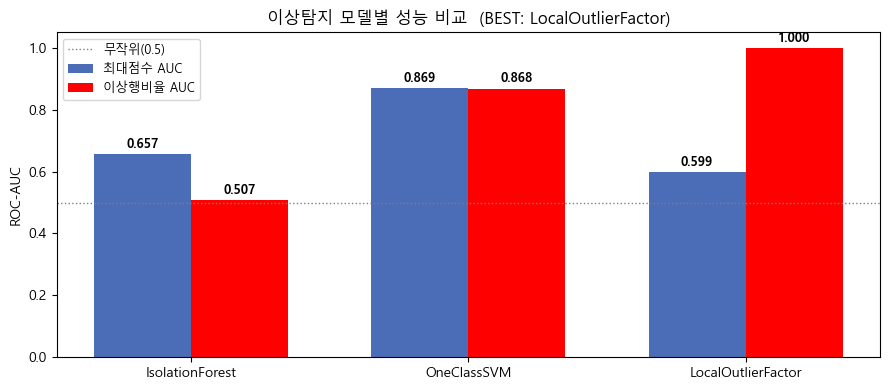

In [54]:
names  = list(results.keys())
auc_mx = [results[n]["maxs"]  for n in names]
auc_rt = [results[n]["ratio"] for n in names]
x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - w/2, auc_mx, w, label="최대점수 AUC",   color="#4b6cb7")
b2 = ax.bar(x + w/2, auc_rt, w, label="이상행비율 AUC", color=RED)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")
ax.axhline(0.5, color="gray", ls=":", lw=1, label="무작위(0.5)")
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("ROC-AUC")
ax.set_title(f"이상탐지 모델별 성능 비교  (BEST: {BEST})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font f

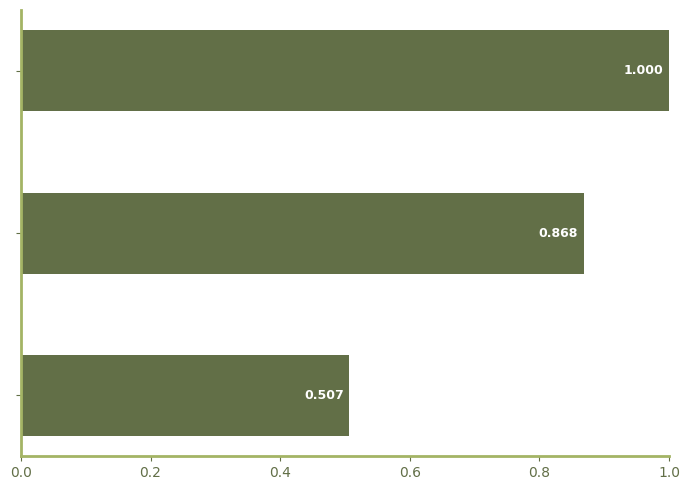

In [55]:
names  = list(results.keys())
auc_rt = [results[n]["ratio"] for n in names]
y = np.arange(len(names))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(y, auc_rt, 0.5, color="#626F47", label="이상행비율 AUC")
for bar in bars:
    ax.text(bar.get_width()-0.07, bar.get_y()+bar.get_height()/2,
            f"{bar.get_width():.3f}", ha="left", va="center",
            fontsize=9, fontweight="bold",color='white',fontfamily='Arimo')
ax.set_yticks(y)
ax.set_yticklabels(['','',''], fontsize=10)
ax.set_xlim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color("#A4B465")
ax.spines['bottom'].set_color("#A4B465")
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='x',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
ax.tick_params(axis='y',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')

plt.tight_layout()
plt.show()

In [56]:
ss = score_all(BEST)
print(df['score'].describe())
print("NaN 개수:", df['score'].isna().sum())
print("상위 5개 점수:")
print(df.nlargest(5, 'score')[['sequence_index','prog','score']])

count    9.690100e+04
mean     7.892931e+04
std      3.773454e+06
min     -5.937725e-01
25%     -5.041260e-01
50%     -4.705116e-01
75%     -3.596391e-01
max      4.027775e+08
Name: score, dtype: float64
NaN 개수: 0
상위 5개 점수:
       sequence_index       prog         score
1437                2   0.000000  4.027775e+08
6060                8   0.000000  3.350091e+08
41331              45   0.000000  3.018378e+08
61113              66  81.879955  2.869747e+08
61114              66  81.993205  2.799065e+08


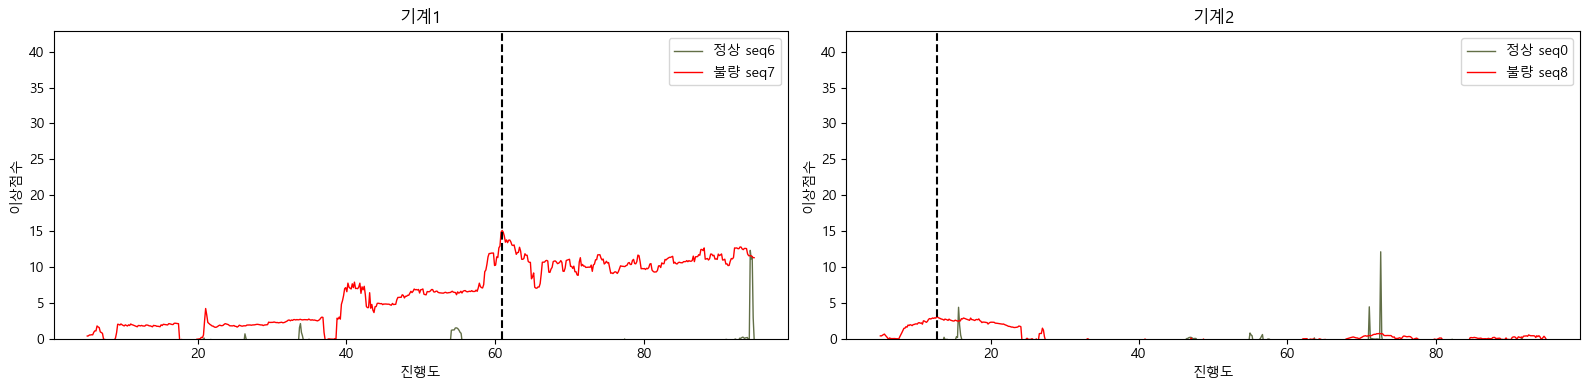

In [57]:
ss = score_all(BEST)
df.loc[(df.prog < 5) | (df.prog > 95), 'score'] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, rec in zip(axes, [1, 2]):
    nid = seqlab[(seqlab.rec == rec) & (seqlab.is_def == 0)].sequence_index.iloc[0]
    did = seqlab[(seqlab.rec == rec) & (seqlab.is_def == 1)].sequence_index.iloc[0]

    for sid, c, l in [(nid, GREEN, "정상"), (did, RED, "불량")]:
        g = df[df.sequence_index == sid].sort_values("prog")
        ax.plot(g.prog, g.score, color=c, lw=1, label=f"{l} seq{sid}")

    g = df[df.sequence_index == did].sort_values("prog")
    ax.set_ylim(0, np.nanpercentile(df.score, 99))

    max_idx = np.nanargmax(g.score.values)
    ax.axvline(g.prog.values[max_idx], color="black", ls="--")

    ax.set_title(f"기계{rec}")
    ax.set_xlabel("진행도")
    ax.set_ylabel("이상점수")
    ax.legend()

plt.tight_layout()
plt.show()

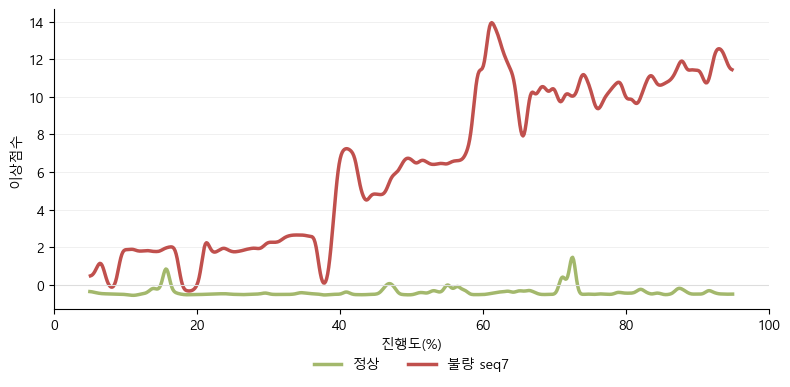

In [58]:
from scipy.ndimage import gaussian_filter1d

ss = score_all(BEST)
df.loc[(df.prog < 5) | (df.prog > 95), "score"] = np.nan

nid = seqlab[seqlab.is_def == 0].sequence_index.iloc[0]
did = seqlab[seqlab.is_def == 1].sequence_index.iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
for sid, color, label in [(nid, "#a3b86c", "정상"), (did, "#c0504d", f"불량 seq{did}")]:
    g = df[df.sequence_index == sid].sort_values("prog").dropna(subset=["score"])
    smooth = gaussian_filter1d(g["score"].values, sigma=3)
    ax.plot(g["prog"], smooth, color=color, lw=2.5, label=label)

ax.axhline(0, color="#ddd", lw=0.8)
ax.set_xlim(0, 100)
ax.set_xlabel("진행도(%)")
ax.set_ylabel("이상점수")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)
ax.grid(axis="y", color="#eee", lw=0.6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

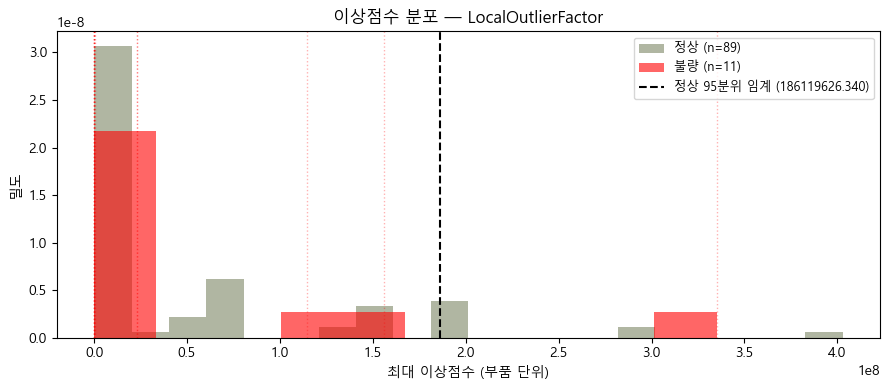

정상: 중앙=4883.568  95분위=186119626.340
불량: 최소=12.008  중앙=421030.422  최대=335009131.468


In [59]:
ss2 = score_all(BEST)
df.loc[(df.prog < 5) | (df.prog > 95), "score"] = np.nan

scores_def  = ss2.loc[ss2.is_def==1, "maxs"].values
scores_norm = ss2.loc[ss2.is_def==0, "maxs"].values
thr_95 = np.percentile(scores_norm, 95)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores_norm, bins=20, alpha=0.5, color=GREEN,
        label=f"정상 (n={len(scores_norm)})", density=True)
ax.hist(scores_def,  bins=10, alpha=0.6, color=RED,
        label=f"불량 (n={len(scores_def)})",  density=True)
ax.axvline(thr_95, color="black", ls="--", lw=1.5,
           label=f"정상 95분위 임계 ({thr_95:.3f})")
for s in scores_def:
    ax.axvline(s, color=RED, alpha=0.3, lw=1, ls=":")
ax.set_xlabel("최대 이상점수 (부품 단위)")
ax.set_ylabel("밀도")
ax.set_title(f"이상점수 분포 — {BEST}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"정상: 중앙={np.median(scores_norm):.3f}  95분위={thr_95:.3f}")
print(f"불량: 최소={scores_def.min():.3f}  중앙={np.median(scores_def):.3f}  최대={scores_def.max():.3f}")

findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font f

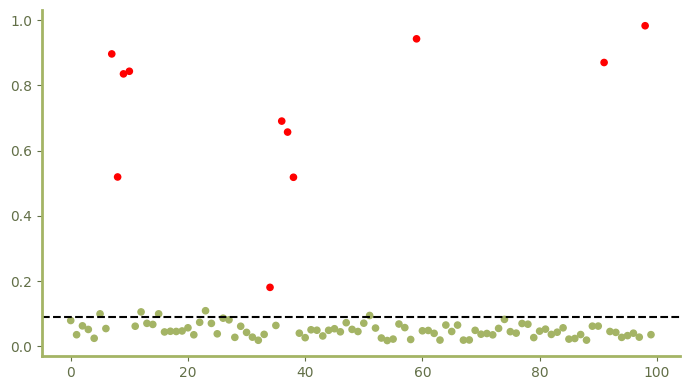

정상 90분위 임계: 재현율 1.00 오탐률 0.10 혼동 [[80, 9], [0, 11]]
정상 95분위 임계: 재현율 1.00 오탐률 0.06 혼동 [[84, 5], [0, 11]]


In [60]:
yd = ss.is_def.values
stat = ss.ratio.values
fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(range(len(stat)), stat, c=[RED if v else "#A4B465" for v in yd], s=20)
ax.axhline(np.quantile(stat[yd==0],0.95), ls="--", color="black")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color("#A4B465")
ax.spines['bottom'].set_color("#A4B465")
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='x',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
ax.tick_params(axis='y',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')

plt.tight_layout()
plt.show()
for q in [0.90,0.95]:
    t = np.quantile(stat[yd==0],q)
    cm = confusion_matrix(yd,(stat>=t).astype(int))
    print(f"정상 {int(q*100)}분위 임계: 재현율 {cm[1,1]/cm[1].sum():.2f} 오탐률 {cm[0,1]/cm[0].sum():.2f} 혼동 {cm.tolist()}")

findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font f

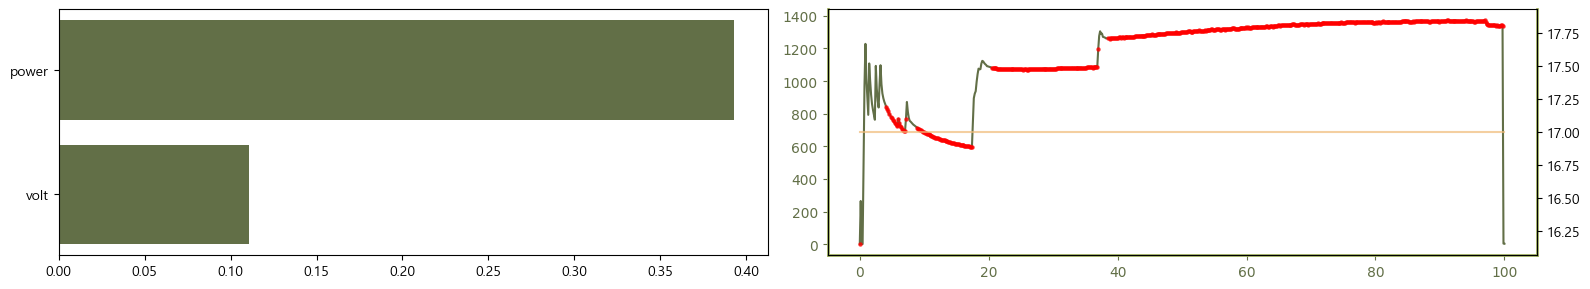

변수 기여 순위: {'power': 0.39, 'volt': 0.11}


In [61]:
flag = df[(df.rowflag==1)&(df.is_def==1)]
base = df[df.is_def==0]
contrib = pd.Series({c: abs((flag[c].mean()-base[c].mean())/(base[c].std()+1e-9)) for c in FB}).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(16,3))
ax[0].barh(contrib.index, contrib.values, color="#626F47")
did = seqlab[seqlab.is_def==1].sequence_index.iloc[0]
g = df[df.sequence_index==did].sort_values("prog")
ax[1].plot(g.prog, g.ampere, color="#626F47", label="전류")
ax2 = ax[1].twinx()
ax2.plot(g.prog, g.temperature, color="#F0BB78", alpha=.7, label="온도")
sp = g[g.rowflag==1]
ax[1].scatter(sp.prog, sp.ampere, color=RED, s=5, zorder=5, label="이상행",alpha=0.7)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(True)
ax[1].spines['left'].set_visible(True)
ax[1].spines['bottom'].set_visible(True)
ax[1].spines['right'].set_color("#A4B465")
ax[1].spines['left'].set_color("#A4B465")
ax[1].spines['bottom'].set_color("#A4B465")
ax[1].spines['right'].set_linewidth(2)
ax[1].spines['left'].set_linewidth(2)
ax[1].spines['bottom'].set_linewidth(2)
ax[1].tick_params(axis='x',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
ax[1].tick_params(axis='y',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
plt.tight_layout()
plt.show()
print("변수 기여 순위:", contrib.sort_values(ascending=False).round(2).to_dict())

findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font f

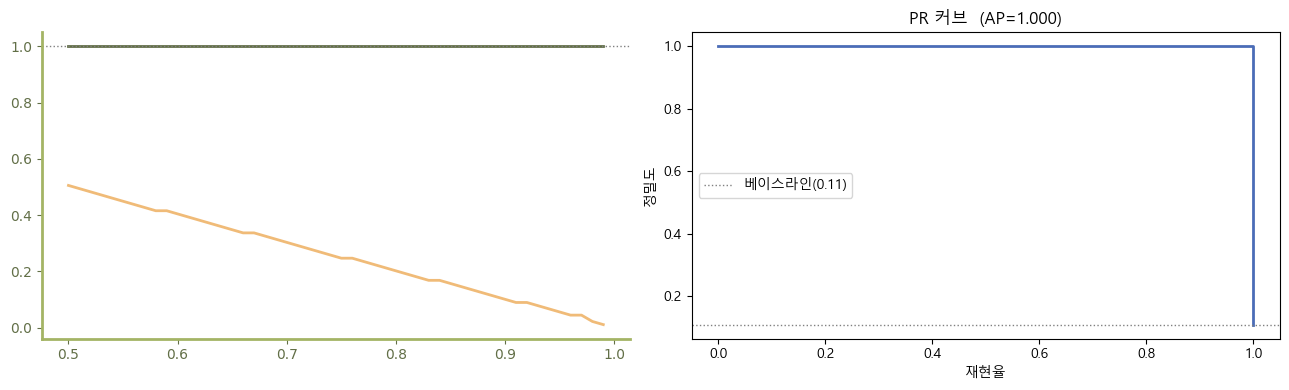

In [62]:
from sklearn.metrics import precision_recall_curve, average_precision_score

yd   = ss.is_def.values
stat = ss[BEST_METRIC].values

quantiles = np.arange(0.50, 1.00, 0.01)
recalls, fprs = [], []
for q in quantiles:
    t    = np.quantile(stat[yd==0], q)
    pred = (stat >= t).astype(int)
    tp = ((pred==1)&(yd==1)).sum()
    fn = ((pred==0)&(yd==1)).sum()
    fp = ((pred==1)&(yd==0)).sum()
    tn = ((pred==0)&(yd==0)).sum()
    recalls.append(tp/(tp+fn) if (tp+fn)>0 else 0)
    fprs.append(fp/(fp+tn)    if (fp+tn)>0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(quantiles, recalls, color="#626F47",   lw=2, label="재현율(Recall)")
axes[0].plot(quantiles, fprs,    color='#F0BB78', lw=2, label="오탐률(FPR)")
axes[0].axhline(1.0, color="gray", ls=":", lw=1)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(True)
axes[0].spines['bottom'].set_visible(True)
axes[0].spines['left'].set_color("#A4B465")
axes[0].spines['bottom'].set_color("#A4B465")
axes[0].spines['left'].set_linewidth(2)
axes[0].spines['bottom'].set_linewidth(2)
axes[0].tick_params(axis='x',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
axes[0].tick_params(axis='y',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')

prec, rec, _ = precision_recall_curve(yd, stat)
ap = average_precision_score(yd, stat)
axes[1].plot(rec, prec, color="#4b6cb7", lw=2)
axes[1].axhline(yd.mean(), color="gray", ls=":", lw=1,
                label=f"베이스라인({yd.mean():.2f})")
axes[1].set_xlabel("재현율")
axes[1].set_ylabel("정밀도")
axes[1].set_title(f"PR 커브  (AP={ap:.3f})")
axes[1].legend()
plt.tight_layout()
plt.show()

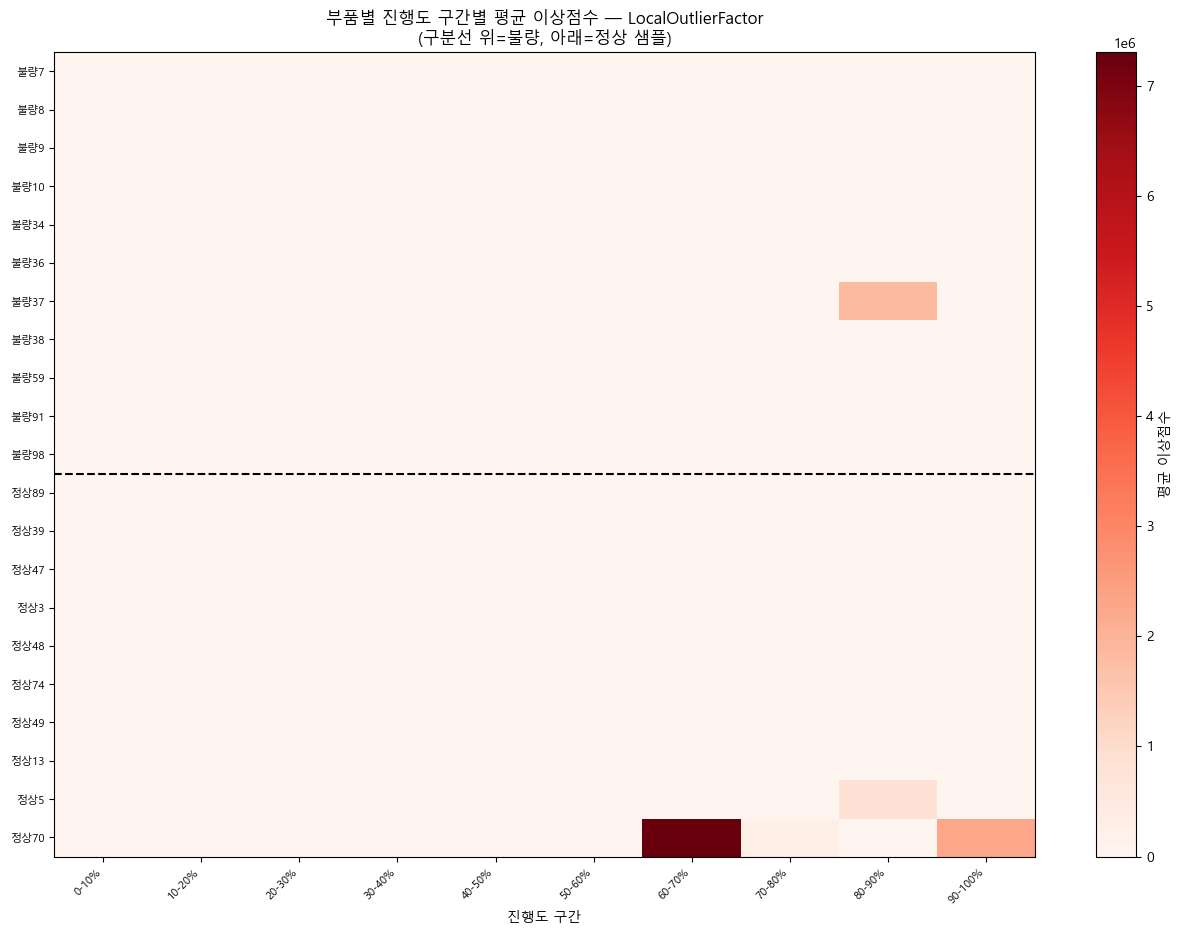

In [63]:
df.loc[(df.prog < 5) | (df.prog > 95), "score"] = np.nan
NBINS = 10
df["prog_bin"] = pd.cut(df["prog"], bins=NBINS, labels=False)

def_seqs  = seqlab[seqlab.is_def==1].sequence_index.values
norm_seqs = seqlab[seqlab.is_def==0].sequence_index.values

def avg_score_by_bin(seqs, prefix):
    rows = {}
    for sid in seqs:
        g = df[df.sequence_index==sid]
        rows[f"{prefix}{int(sid)}"] = g.groupby("prog_bin")["score"].mean()
    return pd.DataFrame(rows).T

hm_def  = avg_score_by_bin(def_seqs, "불량")
hm_norm = avg_score_by_bin(
    np.random.choice(norm_seqs, min(10, len(norm_seqs)), replace=False), "정상")
hm = pd.concat([hm_def, hm_norm]).fillna(0)
hm.columns = [f"{int(i*100/NBINS)}-{int((i+1)*100/NBINS)}%" for i in range(NBINS)]

fig, ax = plt.subplots(figsize=(13, max(4, len(hm)*0.45)))
im = ax.imshow(hm.values, aspect="auto", cmap="Reds")
ax.set_xticks(range(NBINS))
ax.set_xticklabels(hm.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(hm)))
ax.set_yticklabels(hm.index, fontsize=8)
ax.axhline(len(def_seqs)-0.5, color="black", lw=1.5, ls="--")
plt.colorbar(im, ax=ax, label="평균 이상점수")
ax.set_title(
    f"부품별 진행도 구간별 평균 이상점수 — {BEST}\n(구분선 위=불량, 아래=정상 샘플)")
ax.set_xlabel("진행도 구간")
plt.tight_layout()
plt.show()

findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Arimo' not found.
findfont: Font f

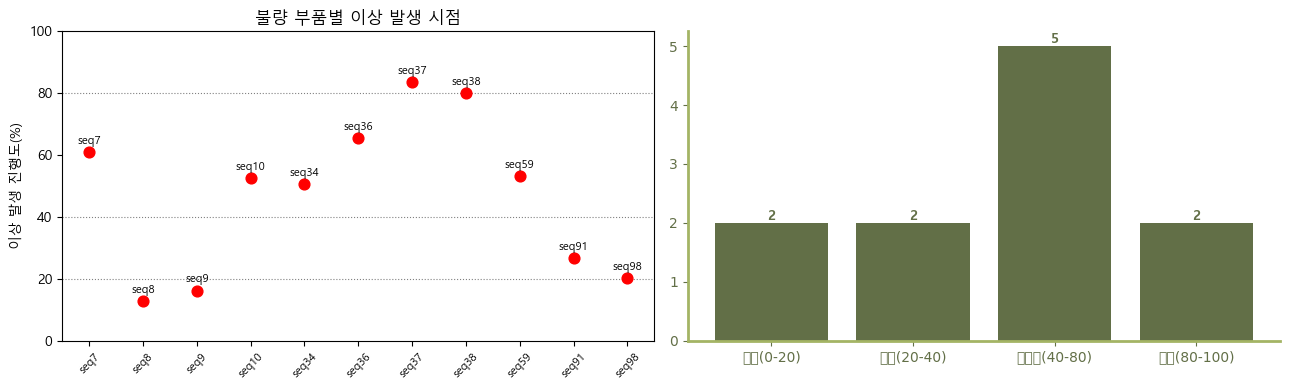

In [64]:
df.loc[(df.prog < 5) | (df.prog > 95), "score"] = np.nan
def_seqs = seqlab[seqlab.is_def==1].sequence_index.values

peak_progs = []
for sid in def_seqs:
    g = df[df.sequence_index==sid].sort_values("prog").dropna(subset=["score"])
    if len(g) == 0:
        peak_progs.append(np.nan)
        continue
    peak_progs.append(float(g.iloc[np.argmax(g.score.values)]["prog"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(range(len(def_seqs)), peak_progs, color=RED, s=60, zorder=3)
for i, (sid, pp) in enumerate(zip(def_seqs, peak_progs)):
    if np.isnan(pp): continue
    axes[0].annotate(f"seq{int(sid)}", (i, pp),
                     textcoords="offset points", xytext=(0, 6),
                     ha="center", fontsize=8)
for pct in [20, 40, 80]:
    axes[0].axhline(pct, color="gray", ls=":", lw=0.8)
axes[0].set_xticks(range(len(def_seqs)))
axes[0].set_xticklabels([f"seq{int(s)}" for s in def_seqs], rotation=45, fontsize=8)
axes[0].set_ylabel("이상 발생 진행도(%)")
axes[0].set_ylim(0, 100)
axes[0].set_title("불량 부품별 이상 발생 시점")

bins_   = [0, 20, 40, 80, 100]
labels_ = ["초기(0-20)", "전환(20-40)", "본공정(40-80)", "종료(80-100)"]
valid   = [p for p in peak_progs if not np.isnan(p)]
counts  = pd.cut(valid, bins=bins_, labels=labels_).value_counts().reindex(labels_)
bars    = axes[1].bar(labels_, counts.values,
                      color=["#626F47" if v > 0 else "gray" for v in counts.values])
for bar, v in zip(bars, counts.values):
    if v > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05,
                     str(v), ha="center", fontweight="bold",color="#626F47")
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(True)
axes[1].spines['bottom'].set_visible(True)
axes[1].spines['left'].set_color("#A4B465")
axes[1].spines['bottom'].set_color("#A4B465")
axes[1].spines['left'].set_linewidth(2)
axes[1].spines['bottom'].set_linewidth(2)
axes[1].tick_params(axis='x',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
axes[1].tick_params(axis='y',direction='out', colors="#626F47", labelsize=10,labelfontfamily='Arimo')
plt.tight_layout()
plt.show()

In [65]:
wide.to_csv(os.path.join(OUT, f"피처_wide_{STAMP}.csv"), index=False, encoding="utf-8-sig")
try: wide.to_parquet(os.path.join(OUT, f"피처_wide_{STAMP}.parquet"), index=False)
except Exception: pass
print("저장 완료:", OUT)

저장 완료: C:/Users/aleet/Desktop/DataAnalysis/내배캠/7_실전프로젝트/data\산출물


## 요약

- 기계1·2는 전류·전력 가동수준이 약하게 다르나 절대이탈 판별력은 통합해도 유지 → 전체 데이터 한 기준 타당
- 단방향 평균은 양방향 상쇄로 비유의, 절대이탈 |z| 는 강하게 유의하고 다중검정 보정 후에도 생존
- 지도학습(RF·XGBoost) 공정변수 기여: 전류 최상위, 전력·전압 순 → 불량 원인 변수
- 결정 임계를 낮춰 불량 누락 최소화, 오탐률 함께 관리
- 이상탐지: 정상만 학습·기계별, LOF 이상행 비율이 시퀀스 분리 우수, recall 우선 임계로 불량 검출
- 이상 점수 급등 시점에서 전류 중심 이탈 확인 — 지도학습 원인 변수와 일치
- 한계: 불량 표본이 적고 임계가 정상 기준 내부 보정이라 분산 큼. 표본 확보 시 재검증 권장

In [66]:
def anomaly_thresholds(df, cols, by_machine=True):
    """이상탐지: 변수별 정상 행 95분위 임계 (기계별)"""
    rows = []
    if by_machine:
        for rec in sorted(df["rec_num"].unique()):
            sub = df[df["rec_num"] == rec]
            normal = sub[sub["is_def"] == 0]
            for c in cols:
                thr = normal[c].quantile(0.95)
                rows.append({"기계": rec, "변수": c, "정상95분위_임계": round(thr, 3)})
    else:
        normal = df[df["is_def"] == 0]
        for c in cols:
            rows.append({"변수": c, "정상95분위_임계": round(normal[c].quantile(0.95), 3)})
    return pd.DataFrame(rows)

athr = anomaly_thresholds(df, RCOLS, by_machine=True)
print("=== 이상탐지 변수별 정상 95분위 임계 (기계별) ===")
print(athr.to_string(index=False))

=== 이상탐지 변수별 정상 95분위 임계 (기계별) ===
 기계        변수  정상95분위_임계
  1  volt_raw     29.100
  1   volt_rm     29.100
  1   volt_rs      2.437
  1  volt_rng      6.100
  1 power_raw  27827.800
  1  power_rm  27705.169
  1  power_rs   1993.087
  1 power_rng   5629.500
  2  volt_raw     30.000
  2   volt_rm     29.794
  2   volt_rs      2.555
  2  volt_rng      6.600
  2 power_raw  22410.000
  2  power_rm  22294.842
  2  power_rs   1666.454
  2 power_rng   4690.100
